In [40]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mne.time_frequency import psd_array_welch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from matplotlib import colors
from typing import List, Optional, Tuple, Dict
from hampel import hampel
from mne_denoise import apply_zapline_to_raw  # you used this later

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"MNE version: {mne.__version__}")

Libraries imported successfully!
MNE version: 1.10.2


## Helpers

In [41]:
# ---- Frequency-domain Hampel (paste BEFORE the batch-processing cell) ----
def apply_freq_domain_hampel(raw, window_size=101, n_sigmas=3):
    raw_hampel = raw.copy()
    data = raw_hampel.get_data()
    n_channels, n_samples = data.shape
    print(f"Applying Frequency Domain Hampel Filter (window={window_size}, sigma={n_sigmas})...")
    for ch_idx in range(n_channels):
        channel_data = data[ch_idx, :]
        fft_coeffs = np.fft.rfft(channel_data)
        magnitude = np.abs(fft_coeffs)
        phase = np.angle(fft_coeffs)
        mag_series = pd.Series(magnitude)
        rolling_median = mag_series.rolling(window=window_size, center=True).median()
        rolling_mad = mag_series.rolling(window=window_size, center=True).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )
        rolling_median = rolling_median.bfill().ffill()
        rolling_mad = rolling_mad.bfill().ffill()
        threshold = n_sigmas * 1.4826 * rolling_mad
        difference = np.abs(magnitude - rolling_median)
        outlier_mask = difference > threshold
        magnitude_filtered = magnitude.copy()
        magnitude_filtered[outlier_mask] = rolling_median[outlier_mask]
        fft_filtered = magnitude_filtered * np.exp(1j * phase)
        data[ch_idx, :] = np.fft.irfft(fft_filtered, n=n_samples)
    raw_hampel._data = data
    print("Freq-domain Hampel complete.")
    return raw_hampel

# ---- Time-domain Hampel (paste BEFORE the batch-processing cell) ----
def apply_time_domain_hampel(raw, window_size=101, n_sigmas=3):
    raw_hampel = raw.copy()
    data = raw_hampel.get_data()
    n_channels, n_samples = data.shape
    print(f"Applying Time Domain Hampel Filter (window={window_size}, sigma={n_sigmas})...")
    for ch_idx in range(n_channels):
        channel_data = data[ch_idx, :]
        series = pd.Series(channel_data)
        rolling_median = series.rolling(window=window_size, center=True).median()
        rolling_mad = series.rolling(window=window_size, center=True).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )
        rolling_median = rolling_median.bfill().ffill()
        rolling_mad = rolling_mad.bfill().ffill()
        threshold = n_sigmas * 1.4826 * rolling_mad
        difference = np.abs(channel_data - rolling_median)
        outlier_mask = difference > threshold
        channel_data_filtered = channel_data.copy()
        channel_data_filtered[outlier_mask] = rolling_median[outlier_mask]
        data[ch_idx, :] = channel_data_filtered
    raw_hampel._data = data
    print("Time-domain Hampel complete.")
    return raw_hampel


### EEG Loader

In [42]:
def load_eeg_data(patient: str, dbs_freq: int, base_path: str) -> tuple:
    # Function to load EEG data based on patient ID, DBS frequency, and sleep state
    # Placeholder implementation
    file_path_sleep = f"{base_path}/{patient}/{patient}SLEEP{dbs_freq}.EDF"
    file_path_awake = f"{base_path}/{patient}/{patient}AWAKE{dbs_freq}.EDF"
    raw_sleep = mne.io.read_raw_edf(file_path_sleep, preload=True, verbose=False)
    raw_awake = mne.io.read_raw_edf(file_path_awake, preload=True, verbose=False)
    return raw_sleep, raw_awake

### Print EEG info

In [43]:
def print_eeg_info(raw):
    print("\n" + "="*60)
    print(f"EEG DATA INFORMATION FOR {raw.info['subject_info']['his_id']}")
    print("="*60)
    print(raw.info)
    print("\nCHANNELS:")
    print(raw.ch_names)
    print("\nDATA DURATION:")
    print(f"{raw.times[-1] / 60:.2f} minutes ({raw.times[-1] / 3600:.2f} hours)")
    print("\nSAMPLING FREQUENCY:")
    print(f"{raw.info['sfreq']} Hz")
    print("\nNUMBER OF CHANNELS:")
    print(f"{len(raw.ch_names)} channels")

### Set custom channels types

In [44]:
def set_custom_channel_types(raw_object):
    """
    Sets channel types for an MNE Raw object based on custom naming conventions.

    This function categorizes channels as 'eeg', 'emg', 'ecg', or 'misc'
    and modifies the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    """
    # Define the standard 10-20 EEG channel names
    eeg_10_20 = {
        'Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2',
        'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz',
        'A1', 'A2'
    } # Using a set for faster lookups
    
    ext_eeg = {'T1', 'T2', 'Fpz'}

    # Use a dictionary comprehension for a more concise approach
    ch_types = {
        ch: 'eeg' if ch in eeg_10_20
        else 'eeg' if ch in ext_eeg
        else 'emg' if ch.startswith('EMG')
        else 'ecg' if ch.startswith('EKG')
        else 'eog' if ch.startswith('LOC') or ch.startswith('ROC')
        else 'misc'
        for ch in raw_object.ch_names
    }

    raw_object.set_channel_types(ch_types)
    print(f"Channel types set for {len(raw_object.ch_names)} channels.")

### set reference

In [45]:
def set_reference(raw_object, ref_channels: list or str = 'average'):
    """
    Sets the reference for an MNE Raw object.

    This function applies a common average reference or a specified reference
    channel to the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    ref_channels : list or str
        List of channel names to use as reference or 'average' for common average reference.
    """
    raw_object.set_eeg_reference(ref_channels=ref_channels)
    print(f"Reference set using channels: {ref_channels}")

In [46]:
def plot_timeseries(raw: mne.io.Raw,
                           picks: Optional[List[str]] = None,
                           start: float = 0,
                           duration: float = 10,
                           title: Optional[str] = None,
                           figsize: Tuple[float, float] = (15, 10),
                           show: bool = True):
    """
    Generates a high-quality, customizable time series plot and returns the figure.

    Defaults to plotting all EEG channels if no 'picks' are provided.
    Allows for custom figure size.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the data.
    picks : list of str, optional
        A specific list of channel names to plot. If None, all 'eeg' channels
        are plotted automatically. Defaults to None.
    start : float, optional
        Start time in seconds for the plot. Defaults to 0.
    duration : float, optional
        Duration of the time window to plot in seconds. Defaults to 10.
    title : str, optional
        Custom title for the plot. If None, a descriptive title is automatically generated.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 10).
    show : bool, optional
        If True, the plot is displayed automatically. Defaults to True.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object for saving or further modification.
    """
    # --- Flexible Channel Selection ---
    if picks is None:
        # Default mode: Automatically find all EEG channels
        channel_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
        plot_mode = 'EEG'
        scalings = dict(eeg=50e-6) # Sensible default scaling for EEG
    else:
        # Manual mode: Use the provided list of channel names
        channel_picks = picks
        plot_mode = 'Custom'
        scalings = 'auto' # Auto-scale when channel types might be mixed

    if len(channel_picks) == 0:
        print(f"Warning: No channels found to plot for mode '{plot_mode}'. Aborting.")
        return None

    # --- Aesthetics for a Nicer Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    channel_color = dict(all='darkslateblue')

    # --- Smart Title Generation ---
    if title is None:
        title = f"{plot_mode} Channels ({len(channel_picks)} selected) from {start:.1f}s to {start + duration:.1f}s"

    # --- Generate the Plot ---
    fig = raw.plot(
        picks=channel_picks,
        start=start,
        duration=duration,
        title=title,
        scalings=scalings,
        color=channel_color,
        show=False, # Must be False to allow for customization before showing
        n_channels=len(channel_picks)
    )

    # --- Apply Customizations ---
    fig.set_size_inches(figsize) # Set the custom figure size
    fig.set_facecolor('white')   # Ensure a clean white background
    plt.tight_layout()           # Adjust layout to prevent labels from overlapping

    if show:
        plt.show()

    return fig

In [47]:
def set_eeg_montage(raw_object, montage_name: str = 'standard_1020'):
    """
    Sets the EEG montage for an MNE Raw object.

    This function applies a standard EEG montage to the Raw object in-place.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object to be modified.
    montage_name : str
        Name of the standard montage to apply. Defaults to 'standard_1020'.
    """
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        raw_object.set_montage(montage, on_missing='warn')
        print("Montage set successfully!")
    except Exception as e:
        print(f"Error setting montage: {e}")

In [48]:
def apply_frequency_filter(raw: mne.io.Raw,
                       l_freq: Optional[float] = None,
                       h_freq: Optional[float] = None,
                       filter_length: str = 'auto',
                       powerline_freq: Optional[float] = None,
                       fir_design: str = 'firwin') -> mne.io.Raw:
    """
    Apply a classic DSP filter to the EEG data.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    l_freq : float | None
        The lower frequency bound for the filter (in Hz).
    h_freq : float | None
        The upper frequency bound for the filter (in Hz).
    filter_length : str
        The length of the filter (e.g., 'auto', '10s', etc.).
    fir_design : str
        The design method for the FIR filter (e.g., 'firwin', 'firls', etc.).

    Returns
    -------
    mne.io.Raw
        The filtered MNE Raw object.
    """
    # Apply the filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design=fir_design)
    # Remove power line noise (it can be 50-60Hz depending on region)
    if powerline_freq is not None:
        raw.notch_filter(freqs=powerline_freq, fir_design=fir_design)
    print(f"Applied bandpass filter: {l_freq} - {h_freq} Hz")

In [49]:
def plot_channel_comparison(raw1: mne.io.Raw,
                            start1: float,
                            raw2: mne.io.Raw,
                            start2: float,
                            channel_name: str,
                            duration: float = 5.0,
                            label1: str = 'Segment 1',
                            label2: str = 'Segment 2',
                            figsize: Tuple[float, float] = (15, 8)):
    """
    Compares two different time segments for a single channel on side-by-side subplots.

    The segments can be from the same or different Raw objects.

    Parameters
    ----------
    raw1 : mne.io.Raw
        The first MNE Raw object.
    start1 : float
        The start time (in seconds) of the first segment.
    raw2 : mne.io.Raw
        The second MNE Raw object. Can be the same as raw1.
    start2 : float
        The start time (in seconds) of the second segment.
    channel_name : str
        The name of the channel to plot (e.g., 'Cz').
    duration : float, optional
        The duration (in seconds) for both plot windows. Defaults to 5.0.
    label1 : str, optional
        The label/title for the first subplot. Defaults to 'Segment 1'.
    label2 : str, optional
        The label/title for the second subplot. Defaults to 'Segment 2'.
    figsize : tuple, optional
        The figure size (width, height) in inches. Defaults to (15, 8).

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object containing the plots.
    """
    # --- Validate that the channel exists in both objects ---
    if channel_name not in raw1.ch_names or channel_name not in raw2.ch_names:
        print(f"Error: Channel '{channel_name}' must exist in both Raw objects.")
        return None

    # --- Prepare data for the first segment ---
    start_samp1, stop_samp1 = raw1.time_as_index([start1, start1 + duration])
    times1 = raw1.times[start_samp1:stop_samp1]
    data1 = raw1.get_data(picks=[channel_name], start=start_samp1, stop=stop_samp1)[0] * 1e6 # Convert to µV

    # --- Prepare data for the second segment ---
    start_samp2, stop_samp2 = raw2.time_as_index([start2, start2 + duration])
    times2 = raw2.times[start_samp2:stop_samp2]
    data2 = raw2.get_data(picks=[channel_name], start=start_samp2, stop=stop_samp2)[0] * 1e6 # Convert to µV

    # --- Create the Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    # Use sharey=True for direct amplitude comparison
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)
    fig.suptitle(f'Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # Plot Segment 1
    axes[0].plot(times1, data1, color='cornflowerblue', linewidth=0.8)
    axes[0].set_title(label1, fontsize=14)
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # Plot Segment 2
    axes[1].plot(times2, data2, color='indianred', linewidth=0.8)
    axes[1].set_title(label2, fontsize=14)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude (µV)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for the main title
    plt.show()

    return fig

In [50]:
def plot_psd_comparison(freqs_up: np.ndarray,
                        psd_up: np.ndarray,
                        channel_name: str,
                        freqs_down: Optional[np.ndarray] = None,
                        psd_down: Optional[np.ndarray] = None,
                        artifact_freqs: Optional[List[float]] = None,
                        fmin: float = 0.0,
                        fmax: float = 100.0,
                        title: Optional[str] = None,
                        subtitle_up: Optional[str] = None,
                        subtitle_down: Optional[str] = None,
                        figsize: Tuple[float, float] = (15, 10)):
    """
    Compares the Power Spectral Density (PSD) of two different datasets for a single channel.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    if freqs_down is None or psd_down is None:
        fig = plt.figure(figsize=figsize)
        fig.suptitle(rf"{title}" if title else f'PSD Plot for Channel: {channel_name}', fontsize=16, fontweight='bold')
        plt.semilogy(freqs_up, psd_up, color='cornflowerblue', linewidth=1.5, label='PSD')
        plt.title(subtitle_up if subtitle_up else 'PSD Plot', fontsize=14)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (µV²/Hz)')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        if artifact_freqs:
            colors = ['red', 'orange', 'purple']
            for i, freq in enumerate(artifact_freqs):
                label = f'{freq} Hz Artifact'
                plt.axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, label=label, alpha=0.7)
            plt.legend(loc='upper right')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        return fig
    
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle(rf"{title}" if title else f'PSD Comparison for Channel: {channel_name}', fontsize=16, fontweight='bold')

    # --- Plot Up Data PSD ---
    axes[0].semilogy(freqs_up, psd_up, color='cornflowerblue', linewidth=1.5, label='Raw PSD')
    axes[0].set_title(rf"{subtitle_up}", fontsize=14)
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Plot Down Data PSD ---
    axes[1].semilogy(freqs_down, psd_down, color='forestgreen', linewidth=1.5, label='Filtered PSD')
    axes[1].set_title(rf"{subtitle_down}", fontsize=14)
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power (µV²/Hz)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Add Artifact Lines to Both Plots ---
    colors = ['red', 'orange', 'purple']
    if artifact_freqs:
        for i, freq in enumerate(artifact_freqs):
            # Add line to raw plot with a clear label
            label = f'{freq} Hz Artifact'
            axes[0].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, label=label, alpha=0.7)
            # Add matching line to filtered plot (without label) for reference
            axes[1].axvline(freq, color=colors[i % len(colors)], linestyle='--',
                            linewidth=1.5, alpha=0.5)

    # Add legends after all lines have been added
    axes[0].legend(loc='upper right')
    axes[1].legend(loc='upper right')

    # --- Apply Final Settings ---
    # Set the custom frequency range on the x-axis
    axes[1].set_xlim(fmin, fmax)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return fig

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Optional, Tuple

def plot_psd_poster_separate(method_psds: Dict[str, Tuple[np.ndarray, np.ndarray]],
                             channel_name: str,
                             dbs_freq: Optional[float] = None,
                             fmax: float = 120.0,
                             zoom_fmax: float = 45.0,
                             harmonic_marker_alpha: float = 0.5,
                             figsize_per_row: Tuple[float,float] = (8, 2.5),
                             title: Optional[str] = None,
                             fname: Optional[str] = None,
                             dpi: int = 300,
                             baseline_name: Optional[str] = None):
    """
    Poster-ready PSD comparison with each method in its own row and two columns:
      [ full-range (0..fmax) | zoom (0..zoom_fmax) ]

    Parameters
    ----------
    method_psds : dict
        Mapping from method name -> (freqs, psd_array). psd_array may be 1D (n_freqs,)
        or 2D (n_channels, n_freqs). If 2D, first row is used.
    channel_name : str
        Name of channel (e.g., 'Cz') used in titles.
    dbs_freq : float | None
        Fundamental DBS frequency. If provided, harmonics up to fmax are shown.
    fmax : float
        Upper x-axis limit for full-range plots.
    zoom_fmax : float
        Upper x-axis limit for zoom plots.
    figsize_per_row : tuple
        Width/height per row; final figsize = (2*width, n_rows*height)
    title : str | None
        Overall figure title.
    fname : str | None
        If provided, save figure to this path.
    baseline_name : str | None
        If provided and present in method_psds, used to compute per-harmonic attenuation inset.
    """
    # Poster-style fonts
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.titlesize": 16
    })

    methods = list(method_psds.keys())
    n = len(methods)
    if n == 0:
        raise ValueError("No methods provided in method_psds")

    # Figure size: 2 columns, n rows
    row_w, row_h = figsize_per_row
    fig_w = row_w * 2
    fig_h = row_h * n
    fig, axes = plt.subplots(n, 2, figsize=(fig_w, fig_h), constrained_layout=False)

    # If only one method, axes will be 1d -> make 2D
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, name in enumerate(methods):
        freqs, psd = method_psds[name]
        freqs = np.asarray(freqs)
        psd_arr = np.asarray(psd)
        if psd_arr.ndim == 2:
            psd_plot = psd_arr[0]
        else:
            psd_plot = psd_arr

        color = palette[i % len(palette)]

        ax_full = axes[i, 0]
        ax_zoom = axes[i, 1]

        # Full-range
        ax_full.semilogy(freqs, psd_plot, color=color, linewidth=1.8)
        ax_full.set_xlim(0, fmax)
        ax_full.set_ylabel("Power (µV²/Hz)")
        ax_full.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
        ax_full.set_title(f"{name} — full (0–{int(fmax)} Hz)")

        # Zoom
        ax_zoom.semilogy(freqs, psd_plot, color=color, linewidth=1.8)
        ax_zoom.set_xlim(0, zoom_fmax)
        ax_zoom.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
        ax_zoom.set_title(f"{name} — zoom (0–{int(zoom_fmax)} Hz)")
        ax_zoom.set_xlabel("Frequency (Hz)")

        # Harmonincs
        if dbs_freq is not None and dbs_freq > 0:
            harmonics = np.arange(dbs_freq, fmax + 1e-6, dbs_freq)
            for hi, h in enumerate(harmonics):
                if h > fmax: break
                label = f"{int(h)} Hz" if (i == 0 and hi == 0) else None  # label only once
                ax_full.axvline(h, color='gray', linestyle=':', alpha=harmonic_marker_alpha, linewidth=1.0, label=label)
                if h <= zoom_fmax:
                    ax_zoom.axvline(h, color='gray', linestyle=':', alpha=harmonic_marker_alpha, linewidth=1.0)

        # Nice ticks
        ax_full.set_xticks(np.linspace(0, fmax, num=7))
        ax_zoom.set_xticks(np.linspace(0, zoom_fmax, num=6))

    # Overall title (top)
    if title:
        fig.suptitle(title, fontsize=18, fontweight='bold')
        # adjust spacing to fit title
        top_margin = 0.95
    else:
        top_margin = 0.98

    # Legend: create a single legend box on top-right with method names & colored markers
    # We'll add legend manually as colored patches
    import matplotlib.patches as mpatches
    patches = [mpatches.Patch(color=palette[i % len(palette)], label=methods[i]) for i in range(len(methods))]
    # place legend to the right of the entire figure
    fig.legend(handles=patches, loc='center right', bbox_to_anchor=(0.99, 0.5), frameon=True)

    # Per-harmonic attenuation inset (if baseline present)
    if baseline_name is not None and baseline_name in method_psds and dbs_freq is not None:
        base_freqs, base_psd = method_psds[baseline_name]
        base_psd = np.asarray(base_psd)
        if base_psd.ndim == 2: base_psd = base_psd[0]
        harmonics = np.arange(dbs_freq, fmax + 1e-6, dbs_freq)
        harmonics = harmonics[harmonics <= fmax]
        mean_atts = {}
        for name in methods:
            freqs_i, psd_i = method_psds[name]
            psd_i = np.asarray(psd_i)
            if psd_i.ndim == 2: psd_i = psd_i[0]
            att_vals = []
            for h in harmonics:
                idx = np.argmin(np.abs(freqs_i - h))
                p_raw = base_psd[idx]
                p_clean = psd_i[idx]
                if p_clean <= 0: p_clean = 1e-20
                att_db = 10 * np.log10(max(p_raw, 1e-20) / p_clean)
                att_vals.append(att_db)
            mean_atts[name] = np.mean(att_vals)
        # draw inset text box on upper-right of the first full-axis
        ax0 = axes[0,0]
        text_lines = ["Mean harmonic attenuation (dB):"]
        for name, v in mean_atts.items():
            text_lines.append(f"{name: <18}: {v:5.1f}")
        bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="0.5", alpha=0.9)
        ax0.text(0.98, 0.95, "\n".join(text_lines), transform=ax0.transAxes,
                 fontsize=10, va='top', ha='right', bbox=bbox_props, family='monospace')

    # adjust layout
    plt.subplots_adjust(left=0.06, right=0.88, top=top_margin, hspace=0.6)

    if fname:
        plt.savefig(fname, dpi=dpi, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show()
    return fig


#### Plot band power topomaps

In [51]:
def plot_band_power_topomaps(raw_object: mne.io.Raw,
                             band_powers: Dict[str, np.ndarray],
                             suptitle: str = "Topographic Distribution of Band Powers",
                             save_path: Optional[str] = None):
    """
    Plots the topographic distribution of power for different frequency bands.

    If channels with standard 10-20 positions are not found, it automatically
    creates fallback bar plots instead.

    Parameters
    ----------
    raw_object : mne.io.Raw
        The MNE Raw object, used for channel information.
    band_powers : dict
        A dictionary where keys are band names (e.g., 'Alpha') and values are
        NumPy arrays of the power for each channel.
    suptitle : str, optional
        The main title for the entire figure.
    save_path : str, optional
        The file path to save the figure. If None, the figure is not saved.
        Example: 'my_figure.png'.

    Returns
    -------
    matplotlib.figure.Figure
        The Matplotlib figure object created.
    """
    try:
        # --- Attempt to Create Topographic Plots ---
        montage = mne.channels.make_standard_montage('standard_1020')
        standard_channels = set(montage.ch_names)

        # Find channels in the data that have a standard 10-20 position
        available_channels = [ch for ch in raw_object.ch_names if ch in standard_channels]

        if not available_channels:
            raise ValueError("No channels with standard 10-20 positions were found.")

        print(f"Found {len(available_channels)} channels with standard positions for plotting.")

        # Create a temporary Raw object with only these channels and set the montage
        raw_temp = raw_object.copy().pick(available_channels)
        raw_temp.set_montage(montage, on_missing='warn')

        # Get the indices of these channels from the original Raw object
        ch_indices = [raw_object.ch_names.index(ch) for ch in available_channels]

        # Filter the band_powers dictionary to only include these channels
        topo_band_powers = {band: powers[ch_indices] for band, powers in band_powers.items()}

        # --- Plotting ---
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(topo_band_powers.items()):
            im, _ = mne.viz.plot_topomap(powers, raw_temp.info, axes=axes[idx], show=False,
                                         cmap='viridis', contours=6)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
            cbar.set_label('Power (µV²)', rotation=270, labelpad=15)

        # Clean up unused subplot if necessary
        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(suptitle, fontsize=18, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])


    except Exception as e:
        # --- Fallback to Bar Plots ---
        print(f"\nCould not create topographic plots: {e}")
        print("Creating alternative bar plots instead...")

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for idx, (band_name, powers) in enumerate(band_powers.items()):
            axes[idx].bar(raw_object.ch_names, powers)
            axes[idx].set_title(band_name, fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Band Power (µV²)')
            axes[idx].grid(True, axis='y', alpha=0.5)
            plt.setp(axes[idx].get_xticklabels(), rotation=90, ha='right')

        if len(band_powers) < len(axes):
            for i in range(len(band_powers), len(axes)):
                fig.delaxes(axes[i])

        fig.suptitle(f"{suptitle} (Bar Plot Fallback)", fontsize=18, fontweight='bold')
        plt.tight_layout()

    # --- Save and Show ---
    if save_path:
        print(f"Saving figure to {save_path}...")
        plt.savefig(save_path, dpi=300)
    plt.show()

    return fig

#### get PSD

In [52]:
def get_psd(raw: mne.io.Raw,
            fmin: float = 0.5,
            fmax: float = 40.0,
            n_fft: int = 2048,
            n_overlap: int = 512,
            n_per_seg: int = 1024) -> tuple:
    """
    Compute the Power Spectral Density (PSD) of EEG data using Welch's method.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the EEG data.
    fmin : float
        Minimum frequency of interest (in Hz).
    fmax : float
        Maximum frequency of interest (in Hz).
    n_fft : int
        Length of the FFT used.
    n_overlap : int
        Number of points to overlap between segments.
    n_per_seg : int
        Length of each segment.

    Returns
    -------
    tuple
        Frequencies and corresponding PSD values.
    """
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')
    data, times = raw[picks, :]
    psds, freqs = psd_array_welch(data, sfreq=raw.info['sfreq'], fmin=fmin, fmax=fmax,
                                  n_fft=n_fft, n_overlap=n_overlap, n_per_seg=n_per_seg)
    return freqs, psds

#### calculate band powers

In [53]:
def calculate_band_powers(psd: np.ndarray,
                          freqs: np.ndarray,
                          ch_names: List[str],
                          bands: Optional[Dict[str, Tuple[float, float]]] = None) -> pd.DataFrame:
    """
    Calculates the power for specified frequency bands from PSD data.

    Parameters
    ----------
    psd : np.ndarray
        The Power Spectral Density data, with shape (n_channels, n_freqs).
    freqs : np.ndarray
        The frequency bins corresponding to the PSD data.
    ch_names : list of str
        A list of channel names that MUST match the channels in the psd array.
    bands : dict, optional
        A dictionary defining the frequency bands. If None, default EEG bands
        are used.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the band power for each channel and band.
    """
    # --- Robustness Check ---
    # Ensure the number of channels in the PSD array matches the number of channel names
    if psd.shape[0] != len(ch_names):
        raise ValueError(
            f"Mismatch in dimensions: PSD has data for {psd.shape[0]} channels, "
            f"but {len(ch_names)} channel names were provided."
        )

    # Use default EEG bands if none are provided
    if bands is None:
        bands = {
            'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
            'Alpha (8-13 Hz)': (8, 13), 'Beta (13-30 Hz)': (13, 30),
            'Gamma (30-40 Hz)': (30, 40)
        }

    band_powers = {}
    for band, (fmin, fmax) in bands.items():
        freq_indices = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        # Use dx=np.diff(freqs)[0] for a more robust integration step
        band_powers[band] = np.trapz(psd[:, freq_indices], dx=np.diff(freqs)[0], axis=1)

    band_power_df = pd.DataFrame(band_powers, index=ch_names)
    band_power_df.index.name = 'Channel'
    return band_power_df

### Save helpers

In [54]:
# Robust save helpers (paste early so they are available)
def save_matplotlib_fig(fig, fname, dpi=300):
    """Robust save for matplotlib/MNE figures."""
    try:
        if hasattr(fig, 'savefig'):
            fig.savefig(fname, dpi=dpi, bbox_inches='tight')
        else:
            plt.gcf().savefig(fname, dpi=dpi, bbox_inches='tight')
    except Exception as e:
        print(f"Warning: could not save via fig.savefig(): {e}. Trying plt.savefig()")
        plt.savefig(fname, dpi=dpi, bbox_inches='tight')
    finally:
        plt.close('all')
    print(f"Saved: {fname}")

In [55]:
def save_psd_raw_vs_filtered(freqs_raw, psd_raw, freqs_filt, psd_filt, ch_idx, channel_name='Cz',
                             fname='psd_raw_vs_filtered.png', max_freq=45):
    plt.figure(figsize=(8,5))
    plt.semilogy(freqs_raw, psd_raw[ch_idx], label='Raw', alpha=0.6)
    plt.semilogy(freqs_filt, psd_filt[ch_idx], label='Filtered (0.5-40 Hz + Notch)', alpha=0.9)
    plt.title(f'Raw vs Filtered PSD — Channel {channel_name}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (µV²/Hz)')
    plt.xlim(0, max_freq)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

In [56]:
def save_psd_method_comparison(psd_freqs, psd_base, psd_zap, psd_spec, psd_hampel_freq, psd_hampel_time,
                               ch_idx, channel_name='Cz', fname='psd_method_comparison.png'):
    plt.figure(figsize=(10,6))
    plt.title(f'DBS Artifact Removal Comparison — Channel {channel_name}')
    plt.semilogy(psd_freqs, psd_base[ch_idx], label='Baseline (BP 0.5-40 Hz)', color='gray', alpha=0.5, linewidth=2)
    plt.semilogy(psd_freqs, psd_zap[ch_idx], label='Zapline', linewidth=1.5)
    plt.semilogy(psd_freqs, psd_spec[ch_idx], label='Spectrum-fit Notch', linewidth=1.5, linestyle='--')
    plt.semilogy(psd_freqs, psd_hampel_freq[ch_idx], label='Freq-domain Hampel', linewidth=1.5, linestyle='-.')
    plt.semilogy(psd_freqs, psd_hampel_time[ch_idx], label='Time-domain Hampel', linewidth=1.5, linestyle=':')
    try:
        for freq in np.arange(dbs_freq, 45+1, dbs_freq):
            plt.axvline(freq, color='orange', linestyle=':', alpha=0.4)
    except Exception:
        pass
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (µV²/Hz)')
    plt.xlim(0, 45)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

In [57]:
def save_topomap_panel(df_before, df_after, montage_info, bands_dict, fname='topomaps_before_after.png'):
    n_bands = len(bands_dict)
    ncols = n_bands
    fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 8))
    fig.suptitle("Topographic Power: Before (top) vs After (bottom)", fontsize=16, fontweight='bold')
    for i, band in enumerate(bands_dict.keys()):
        vals_before = df_before[band].values
        vals_after = df_after[band].values
        vmax = max(df_before[band].max(), df_after[band].max())
        im, _ = mne.viz.plot_topomap(vals_before, montage_info, axes=axes[0, i], show=False,
                                     cmap='viridis', vlim=(0, vmax), contours=6)
        axes[0, i].set_title(f"Before: {band}", fontsize=11)
        im2, _ = mne.viz.plot_topomap(vals_after, montage_info, axes=axes[1, i], show=False,
                                      cmap='viridis', vlim=(0, vmax), contours=6)
        axes[1, i].set_title(f"After: {band}", fontsize=11)
        cbar = plt.colorbar(im2, ax=axes[:, i], fraction=0.05, pad=0.04, orientation='horizontal')
        cbar.set_label('Power (µV²)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

In [58]:
def save_time_domain_comparison(raw1, start1, raw2, start2, channel_name, duration, fname='time_domain_comparison.png'):
    fig = plot_channel_comparison(raw1, start1, raw2, start2, channel_name=channel_name, duration=duration, show=False)
    try:
        save_matplotlib_fig(fig, fname)
    except Exception:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved (fallback): {fname}")

In [59]:
def save_ica_overlay_and_bipolar(raw_pre_ica, raw_post_ica, ica_obj, fname_overlay='ica_overlay.png', fname_bipolar='bipolar_montage.png'):
    try:
        fig_overlay = ica_obj.plot_overlay(raw_pre_ica, exclude=ica_obj.exclude, picks='eeg', show=False)
        save_matplotlib_fig(fig_overlay, fname_overlay)
    except Exception as e:
        print("ICA overlay save failed:", e)
    try:
        fig = plot_bipolar_montage(raw_post_ica, start=0, duration=10, title="Bipolar Montage (Cleaned)")
        save_matplotlib_fig(fig, fname_bipolar)
    except Exception as e:
        print("Bipolar montage save failed:", e)

## Execution: load → preprocess → compare methods → save figures

In [60]:
# start with XU 7 DBS
patient = "XU"
dbs_freq = 7  # in Hz
base_path = "../data"
powerline_freq = 60.0  # in Hz
raw_sleep, raw_awake = load_eeg_data(patient, dbs_freq, base_path)

In [21]:
# Basic info prints
print_eeg_info(raw_sleep)
print_eeg_info(raw_awake)


EEG DATA INFORMATION FOR X
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-05-11 00:22:15 UTC
 nchan: 46
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, first_name: X, last_name: X>
>

CHANNELS:
['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2', 'Fpz', 'Pz', 'T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR']

DATA DURATION:
10.63 minutes (0.18 hours)

SAMPLING FREQUENCY:
256.0 Hz

NUMBER OF CHANNELS:
46 channels

EEG DATA INFORMATION FOR X
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 

In [22]:
# Channel types & montage & reference
set_custom_channel_types(raw_sleep)
set_custom_channel_types(raw_awake)
set_eeg_montage(raw_sleep)
set_eeg_montage(raw_awake)
set_reference(raw_sleep)  # common average
set_reference(raw_awake)

Channel types set for 46 channels.
Channel types set for 46 channels.
Montage set successfully!
Montage set successfully!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average


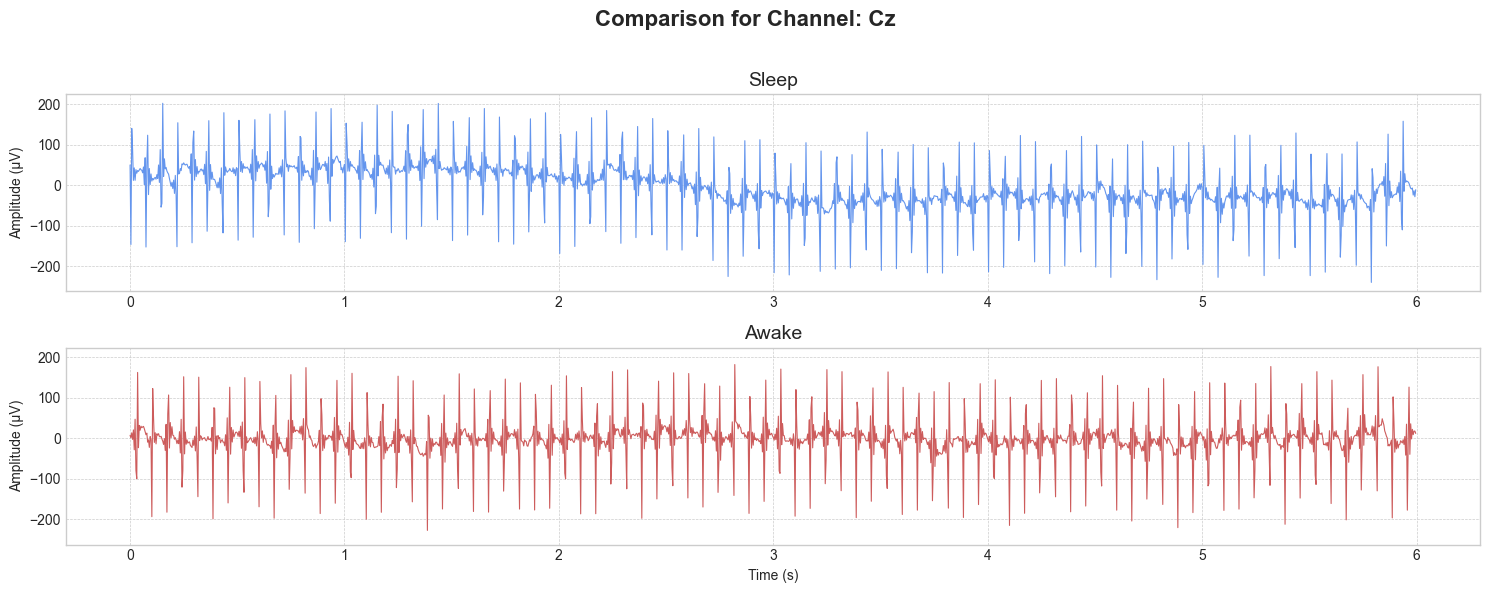

In [23]:
fig_xu7_sleep = plot_channel_comparison(raw_sleep, raw2=raw_awake, start1=0, start2=0,
                                       channel_name='Cz', duration=6.0, label1='Sleep', label2='Awake', figsize=(15, 6))

In [24]:
save_matplotlib_fig(fig_xu7_sleep, 'images/time_domain_sleep_vs_awake_Cz.png')

Saved: images/time_domain_sleep_vs_awake_Cz.png


### Compute raw PSDs (before any filtering) and visualize

In [25]:
psd_raw_sleep_freqs, psd_raw_sleep = get_psd(raw_sleep, fmax=128.0)
psd_raw_awake_freqs, psd_raw_awake = get_psd(raw_awake, fmax=128.0)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


In [26]:
artifact_freqs = [dbs_freq * n for n in range(1, 20)]  # e.g., [7, 14, 21, 28, 35]

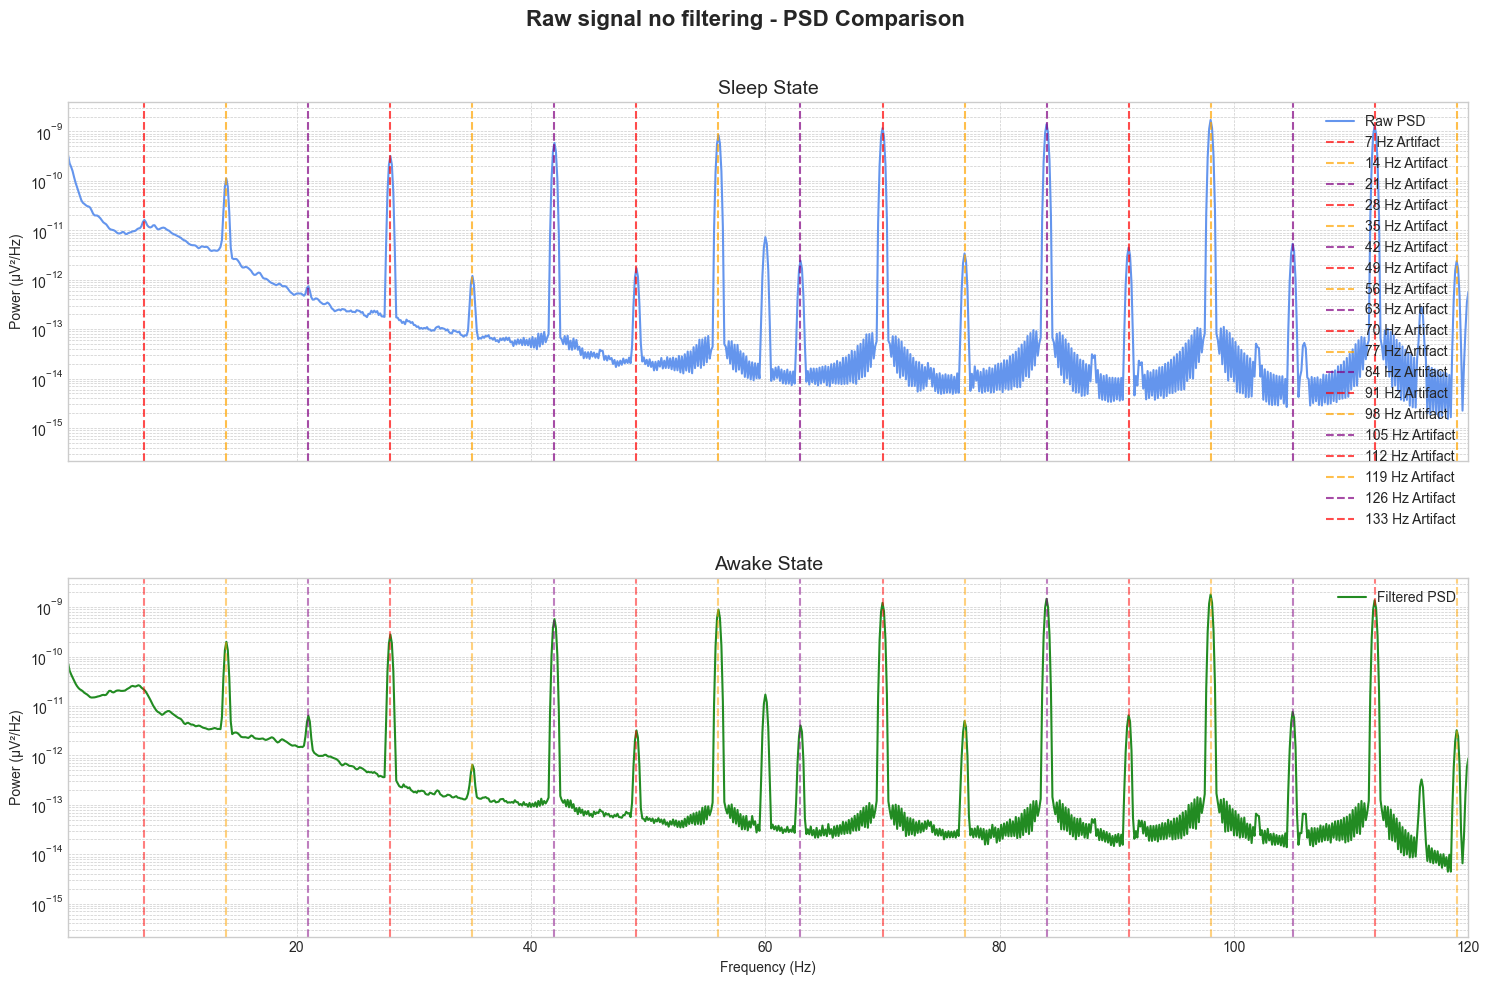

In [33]:
# PSD comparison raw sleep vs awake (save)
fig = plot_psd_comparison(
    freqs_up=psd_raw_sleep_freqs,
    psd_up=psd_raw_sleep[raw_sleep.ch_names.index('Cz')],
    freqs_down=psd_raw_awake_freqs,
    psd_down=psd_raw_awake[raw_awake.ch_names.index('Cz')],
    channel_name='Cz',
    fmin=0.5,
    fmax=120.0,
    title='Raw signal no filtering - PSD Comparison',
    subtitle_up='Sleep State',
    subtitle_down='Awake State',
    artifact_freqs=artifact_freqs
)

# save the displayed figure
fig.savefig('psd_raw_sleep_vs_awake_Cz.png', dpi=300, bbox_inches='tight')

Saved: psd_sleep_vs_awake_cz_separate.png


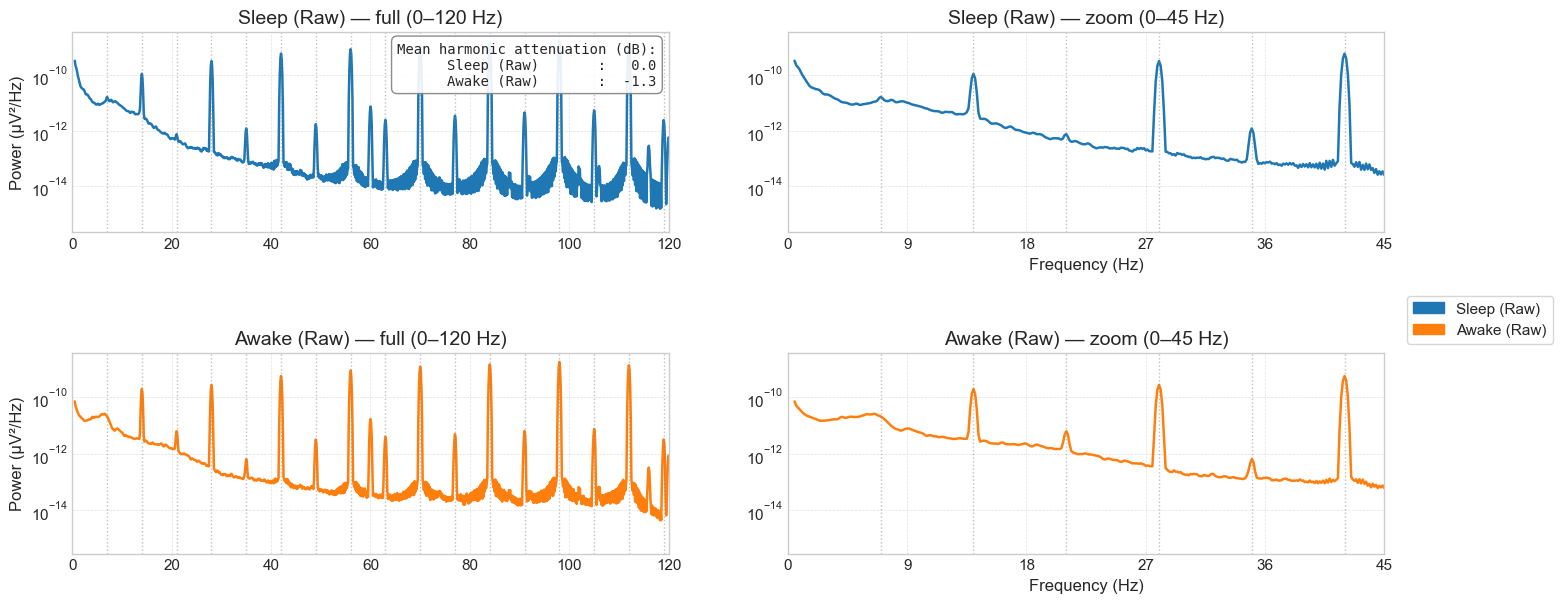

In [71]:
method_psds = {
    "Sleep (Raw)": (psd_raw_sleep_freqs, psd_raw_sleep[raw_sleep.ch_names.index('Cz')]),
    "Awake (Raw)": (psd_raw_awake_freqs, psd_raw_awake[raw_awake.ch_names.index('Cz')])
}

fig = plot_psd_poster_separate(
    method_psds=method_psds,
    channel_name='Cz',
    dbs_freq=dbs_freq,
    fmax=120.0,
    zoom_fmax=45.0,
    figsize_per_row=(8, 3),   # (width_per_col, height_per_row)
    title="",
    fname="psd_sleep_vs_awake_cz_separate.png",
    baseline_name="Sleep (Raw)"
)

### Apply baseline preprocessing: filtering + notch

In [29]:
filtered_sleep = raw_sleep.copy()
apply_frequency_filter(filtered_sleep, l_freq=0.5, h_freq=40.0, powerline_freq=powerline_freq)
filtered_awake = raw_awake.copy()
apply_frequency_filter(filtered_awake, l_freq=0.5, h_freq=40.0, powerline_freq=powerline_freq)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

In [30]:
# PSD after baseline filtering
psd_filt_sleep_freqs, psd_filt_sleep = get_psd(filtered_sleep, fmax=128.0)
psd_filt_awake_freqs, psd_filt_awake = get_psd(filtered_awake, fmax=128.0)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


In [31]:
# Save raw vs filtered PSD (Block A - left)
ch_idx = filtered_sleep.ch_names.index('Cz')
save_psd_raw_vs_filtered(psd_raw_sleep_freqs, psd_raw_sleep, psd_filt_sleep_freqs, psd_filt_sleep, ch_idx,
                         channel_name='Cz', fname='psd_raw_vs_filtered_Cz.png', max_freq = 120)


Saved: psd_raw_vs_filtered_Cz.png


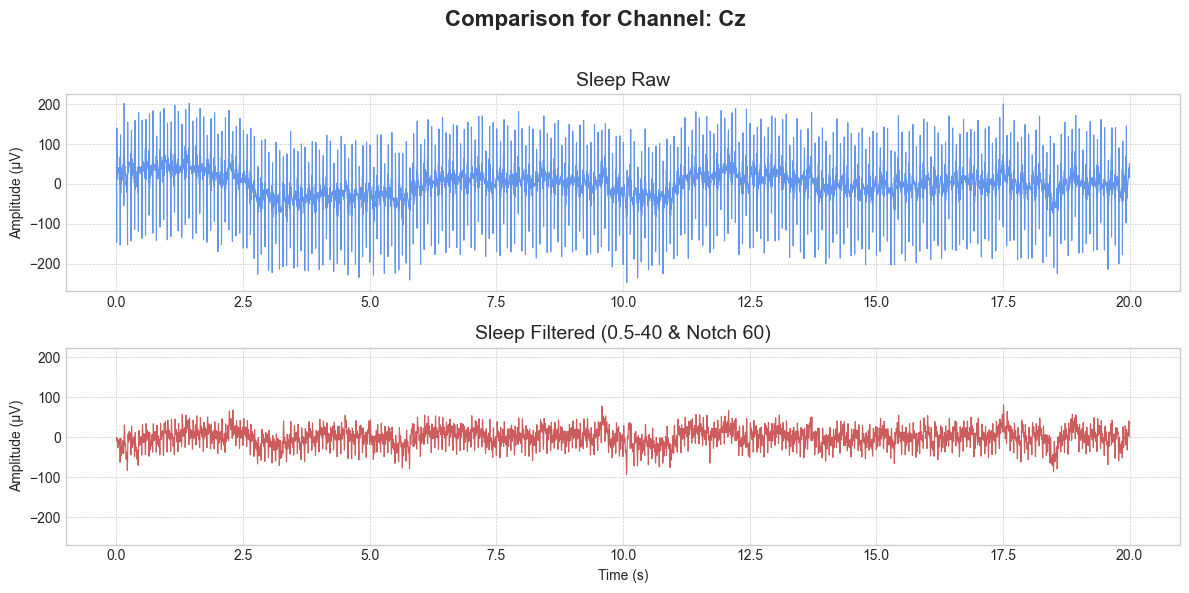

Saved: time_domain_raw_vs_filtered_Cz.png


In [34]:
# Also save time-domain before vs after filtering
fig_td = plot_channel_comparison(raw_sleep, start1=0, raw2=filtered_sleep, start2=0,
                                channel_name='Cz', duration=20.0,
                                label1='Sleep Raw', label2='Sleep Filtered (0.5-40 & Notch 60)', figsize=(12,6))
save_matplotlib_fig(fig_td, 'time_domain_raw_vs_filtered_Cz.png')

### DBS artifact removal: run methods and compute PSDs for each

In [35]:
# Prepare harmonics
sfreq = filtered_sleep.info['sfreq']
dbs_harmonics = np.arange(dbs_freq, sfreq / 2, dbs_freq)
powerline_harmonics = np.arange(powerline_freq, sfreq / 2, powerline_freq)
freqs_to_remove = np.union1d(dbs_harmonics, powerline_harmonics)

In [36]:
print("\n--- Method 1: Zapline (All Harmonics) ---")
raw_zapline, _scores, _details, _freqs = apply_zapline_to_raw(filtered_sleep.copy(), line_freqs=dbs_harmonics, verbose=True)


--- Method 1: Zapline (All Harmonics) ---
Data set is short. Adjusted window size for whole-spectrum calculation to 79.0 seconds.


## FAST



=== Processing state: SLEEP ===
Channel types set for 46 channels.
Montage set successfully!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average
Effective window size : 8.000 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero

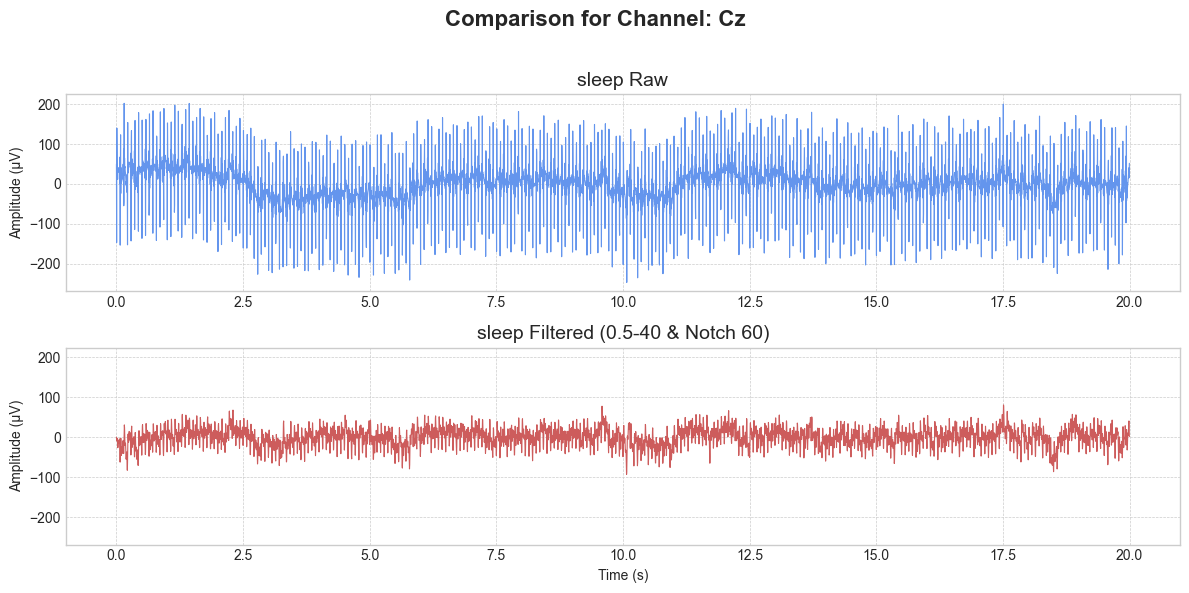

Saved: time_domain_raw_vs_filtered_Cz_sleep.png
Data set is short. Adjusted window size for whole-spectrum calculation to 79.0 seconds.
Freq-domain Hampel failed for sleep: name 'apply_freq_domain_hampel' is not defined
Time-domain Hampel failed for sleep: name 'apply_time_domain_hampel' is not defined
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Saved: psd_method_comparison_Cz_sleep.png


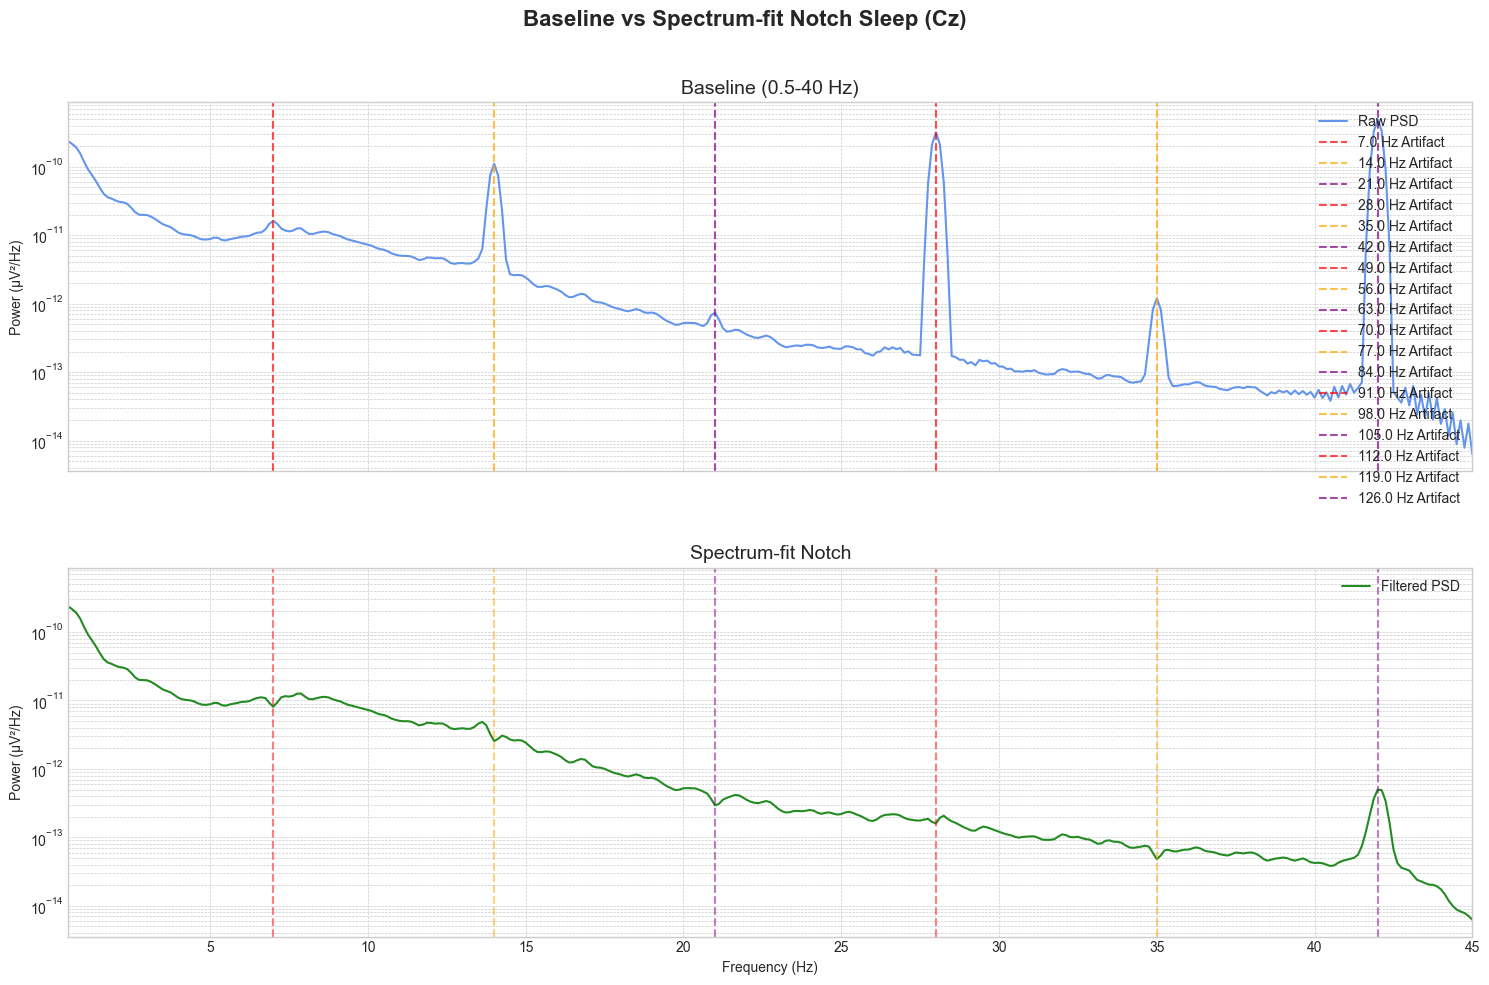

Saved: psd_baseline_vs_spectrumfit_Cz_sleep.png
Metrics computation failed for sleep: name 'calculate_quality_metrics' is not defined
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

Using EOG channels: Fp1, Fp2
EOG channel index for this subject is: [ 0 11]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp2 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) metho

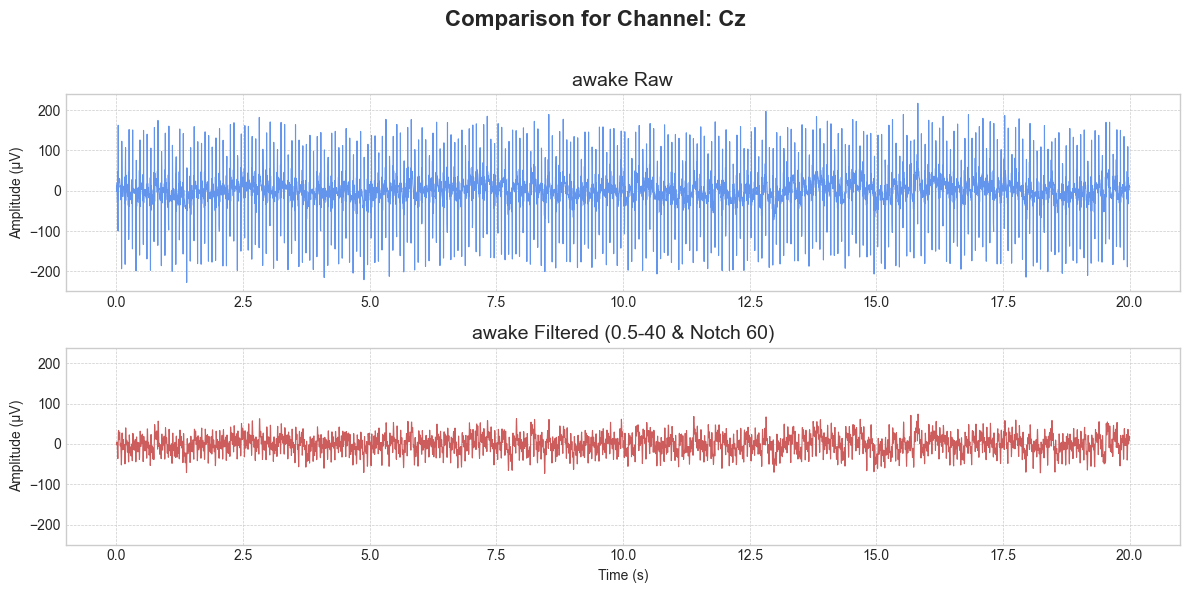

Saved: time_domain_raw_vs_filtered_Cz_awake.png
Data set is short. Adjusted window size for whole-spectrum calculation to 71.0 seconds.
Freq-domain Hampel failed for awake: name 'apply_freq_domain_hampel' is not defined
Time-domain Hampel failed for awake: name 'apply_time_domain_hampel' is not defined
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Saved: psd_method_comparison_Cz_awake.png


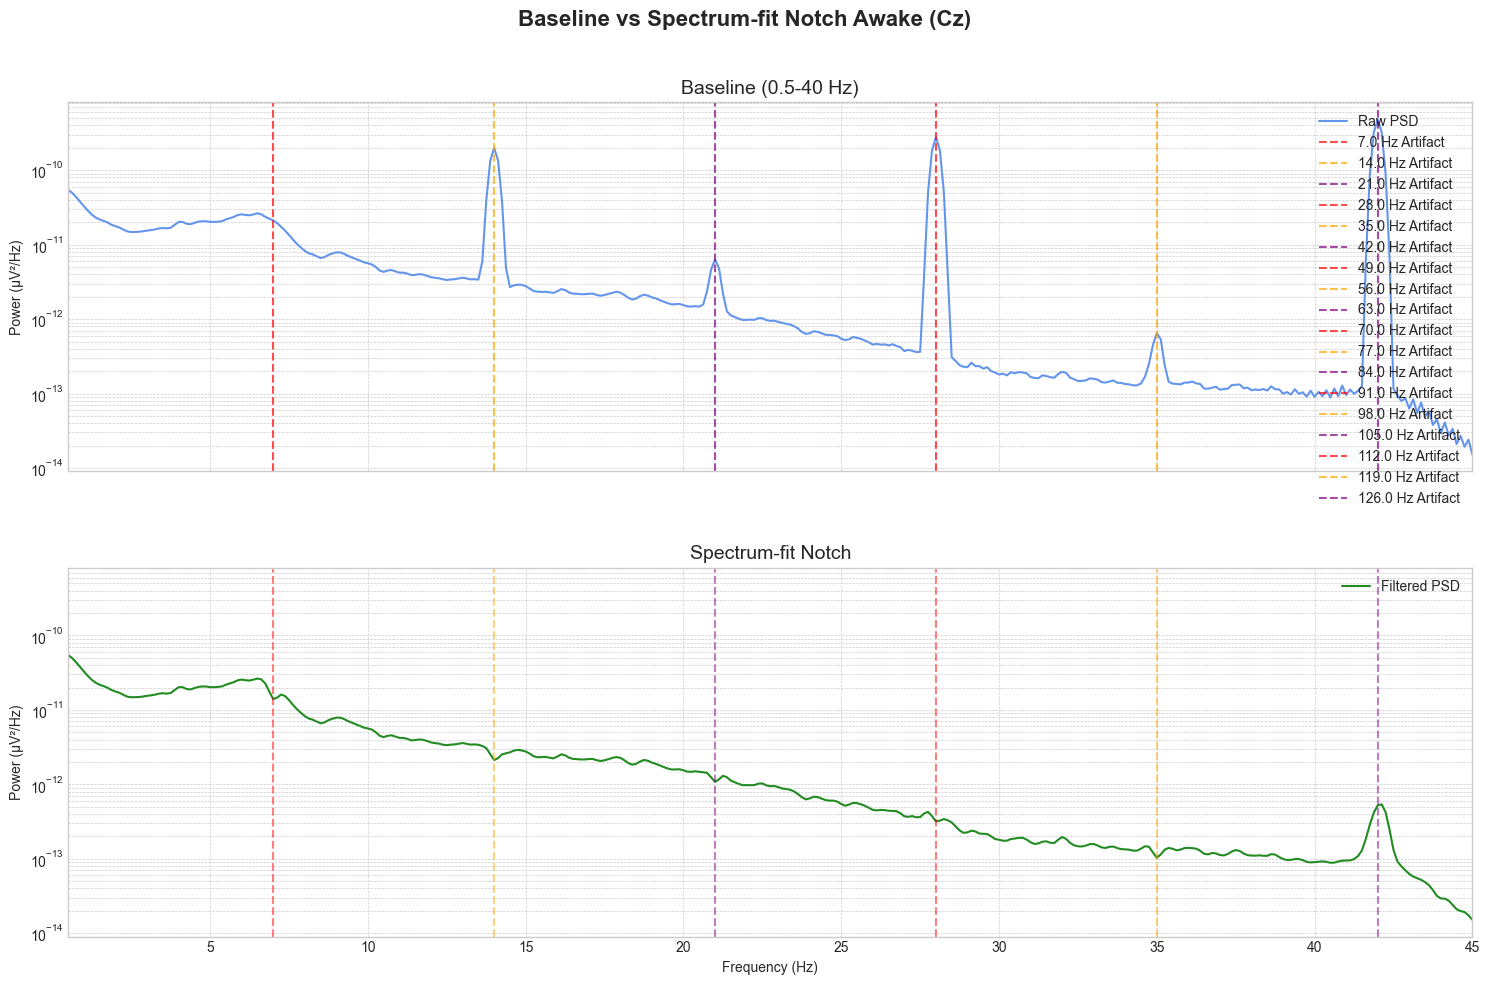

Saved: psd_baseline_vs_spectrumfit_Cz_awake.png
Metrics computation failed for awake: name 'calculate_quality_metrics' is not defined
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)

Using EOG channels: Fp1, Fp2
EOG channel index for this subject is: [ 0 11]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) metho

In [37]:
# %% [markdown]
# ### Batch processing & figure saving for both Sleep and Awake

# %%
states = {'sleep': raw_sleep, 'awake': raw_awake}
saved_files = []

for state_name, raw in states.items():
    try:
        print(f"\n\n=== Processing state: {state_name.upper()} ===")
        suffix = f"_{state_name}"

        # 1) Basic info & set types/montage/reference (if not already applied)
        try:
            set_custom_channel_types(raw)
        except Exception as e:
            print(f"Warning setting channel types for {state_name}: {e}")
        try:
            set_eeg_montage(raw)
        except Exception as e:
            print(f"Warning setting montage for {state_name}: {e}")
        try:
            set_reference(raw)
        except Exception as e:
            print(f"Warning setting reference for {state_name}: {e}")

        # 2) Save a time-domain comparison vs the other state (optional)
        # We'll skip cross-state TD here to avoid duplication; you already saved sleep vs awake earlier.

        # 3) Compute raw PSD (before filtering)
        freqs_raw, psd_raw = get_psd(raw, fmax=128.0)
        ch_idx = raw.ch_names.index('Cz') if 'Cz' in raw.ch_names else 0

        # 4) Baseline preprocessing: copy + filter + notch
        filtered = raw.copy()
        apply_frequency_filter(filtered, l_freq=0.5, h_freq=40.0, powerline_freq=powerline_freq)
        # compute filtered PSD
        freqs_filt, psd_filt = get_psd(filtered, fmax=128.0)

        # Save raw vs filtered PSD
        fname_psd_raw_filt = f'psd_raw_vs_filtered_Cz{suffix}.png'
        save_psd_raw_vs_filtered(freqs_raw, psd_raw, freqs_filt, psd_filt, ch_idx,
                                 channel_name='Cz', fname=fname_psd_raw_filt)
        saved_files.append(fname_psd_raw_filt)

        # Save time-domain before vs after filtering (Cz)
        try:
            fig_td = plot_channel_comparison(raw, start1=0, raw2=filtered, start2=0,
                                            channel_name='Cz', duration=20.0,
                                            label1=f'{state_name} Raw', label2=f'{state_name} Filtered (0.5-40 & Notch 60)',
                                            figsize=(12,6))
            fname_td_raw_filt = f'time_domain_raw_vs_filtered_Cz{suffix}.png'
            save_matplotlib_fig(fig_td, fname_td_raw_filt)
            saved_files.append(fname_td_raw_filt)
        except Exception as e:
            print(f"Could not save time-domain raw vs filtered for {state_name}: {e}")

        # 5) DBS artifact removal methods
        sfreq_local = filtered.info['sfreq']
        dbs_harmonics_local = np.arange(dbs_freq, sfreq_local / 2, dbs_freq)
        powerline_harmonics_local = np.arange(powerline_freq, sfreq_local / 2, powerline_freq)
        freqs_to_remove_local = np.union1d(dbs_harmonics_local, powerline_harmonics_local)

        # Method 1: Zapline
        try:
            raw_zapline, _scores, _details, _freqs = apply_zapline_to_raw(filtered.copy(),
                                                                           line_freqs=dbs_harmonics_local, verbose=False)
        except Exception as e:
            print(f"Zapline failed for {state_name}: {e}")
            raw_zapline = filtered.copy()

        # Method 2: Spectrum-fit notch
        try:
            raw_spectrum_fit = filtered.copy().notch_filter(freqs=freqs_to_remove_local,
                                                           method='spectrum_fit', n_jobs=1, verbose=False)
        except Exception as e:
            print(f"Spectrum-fit notch failed for {state_name}: {e}")
            raw_spectrum_fit = filtered.copy()

        # Method 3: Frequency-domain Hampel
        try:
            raw_hampel_freq = apply_freq_domain_hampel(filtered.copy(), window_size=101, n_sigmas=3)
        except Exception as e:
            print(f"Freq-domain Hampel failed for {state_name}: {e}")
            raw_hampel_freq = filtered.copy()

        # Method 4: Time-domain Hampel
        try:
            raw_hampel_time = apply_time_domain_hampel(filtered.copy(), window_size=101, n_sigmas=3)
        except Exception as e:
            print(f"Time-domain Hampel failed for {state_name}: {e}")
            raw_hampel_time = filtered.copy()

        # 6) Compute PSDs (fmax for poster clarity)
        fmax_plot = 45.0
        psd_base_freqs, psd_base = get_psd(filtered, fmax=fmax_plot)
        _, psd_zap = get_psd(raw_zapline, fmax=fmax_plot)
        _, psd_spec = get_psd(raw_spectrum_fit, fmax=fmax_plot)
        _, psd_hampel_freq = get_psd(raw_hampel_freq, fmax=fmax_plot)
        _, psd_hampel_time = get_psd(raw_hampel_time, fmax=fmax_plot)

        # 7) Save method comparison PSD
        fname_method_comp = f'psd_method_comparison_Cz{suffix}.png'
        save_psd_method_comparison(psd_base_freqs, psd_base, psd_zap, psd_spec, psd_hampel_freq, psd_hampel_time,
                                   ch_idx, channel_name='Cz', fname=fname_method_comp)
        saved_files.append(fname_method_comp)

        # Save baseline vs spectrum-fit example
        try:
            fig_example = plot_psd_comparison(freqs_up=psd_base_freqs, psd_up=psd_base[ch_idx],
                                             freqs_down=psd_base_freqs, psd_down=psd_spec[ch_idx],
                                             channel_name='Cz', fmin=0.5, fmax=45.0,
                                             title=f'Baseline vs Spectrum-fit Notch {state_name.capitalize()} (Cz)',
                                             subtitle_up='Baseline (0.5-40 Hz)',
                                             subtitle_down='Spectrum-fit Notch',
                                             artifact_freqs=list(dbs_harmonics_local))
            fname_example = f'psd_baseline_vs_spectrumfit_Cz{suffix}.png'
            plt.savefig(fname_example, dpi=300, bbox_inches='tight')
            plt.close()
            saved_files.append(fname_example)
            print(f"Saved: {fname_example}")
        except Exception as e:
            print(f"Could not save baseline vs spectrum-fit PSD for {state_name}: {e}")

        # 8) Quantitative metrics for this state
        try:
            results = []
            results.append(calculate_quality_metrics(psd_base[ch_idx], psd_zap[ch_idx], psd_base_freqs, dbs_freq, 'Zapline'))
            results.append(calculate_quality_metrics(psd_base[ch_idx], psd_spec[ch_idx], psd_base_freqs, dbs_freq, 'Spectrum Fit'))
            results.append(calculate_quality_metrics(psd_base[ch_idx], psd_hampel_freq[ch_idx], psd_base_freqs, dbs_freq, 'Freq-Domain Hampel'))
            results.append(calculate_quality_metrics(psd_base[ch_idx], psd_hampel_time[ch_idx], psd_base_freqs, dbs_freq, 'Time-Domain Hampel'))
            df_results_state = pd.DataFrame(results)
            csv_name = f'quality_metrics_table{suffix}.csv'
            df_results_state.to_csv(csv_name, index=False)
            saved_files.append(csv_name)

            # Save metrics plot
            df_melted = df_results_state.melt(id_vars="Method", var_name="Metric", value_name="Value")
            plt.figure(figsize=(10,8))
            plt.subplot(2, 1, 1)
            metrics_db = ['Artifact Attenuation (dB)', 'SNR Improvement (dB)']
            sns.barplot(data=df_melted[df_melted['Metric'].isin(metrics_db)], x='Metric', y='Value', hue='Method', palette='viridis')
            plt.title(f'Noise Reduction Performance — {state_name.capitalize()}')
            plt.ylabel('Decibels (dB)')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.subplot(2, 1, 2)
            metrics_pct = ['Signal Preservation (Broadband) %', 'Alpha Band Preservation %']
            sns.barplot(data=df_melted[df_melted['Metric'].isin(metrics_pct)], x='Metric', y='Value', hue='Method', palette='viridis')
            plt.title('Signal Preservation (Closer to 100% is Better)')
            plt.ylabel('Percentage (%)')
            plt.axhline(100, color='red', linestyle='--', alpha=0.5)
            plt.ylim(80, 110)
            plt.tight_layout()
            metrics_fname = f'quality_metrics_comparison{suffix}.png'
            plt.savefig(metrics_fname, dpi=300, bbox_inches='tight')
            plt.close()
            saved_files.append(metrics_fname)
            print(f"Saved metrics for {state_name}: {metrics_fname}, {csv_name}")
        except Exception as e:
            print(f"Metrics computation failed for {state_name}: {e}")

        # 9) Run ICA on spectrum-fit cleaned data (example) and save overlays + bipolar + frontal time-domain
        try:
            clean_for_ica = raw_spectrum_fit.copy()
            # Remove extra channels if present
            drop_chs = [ch for ch in ['T1', 'T2', 'Fpz'] if ch in clean_for_ica.ch_names]
            if drop_chs:
                clean_for_ica.drop_channels(drop_chs)
            clean_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')
            # Create EOG evoked only if EOG channels exist
            eog_chs = [c for c in ['Fp1','Fp2'] if c in clean_for_ica.ch_names]
            if len(eog_chs) > 0:
                try:
                    eog_evoked = mne.preprocessing.create_eog_epochs(clean_for_ica, ch_name=eog_chs).average()
                    eog_evoked.apply_baseline(baseline=(None, -0.2))
                except Exception:
                    pass
            # Fit ICA
            ica_state = mne.preprocessing.ICA(n_components=15, random_state=97, max_iter='auto', verbose=False)
            ica_state.fit(clean_for_ica, picks='eeg')
            # Example: interactive inspection is recommended; here we use placeholders for excluded comps
            # You should set `ica_exclude_state` manually after inspecting components.
            ica_exclude_state = [1, 8, 10]  # adapt after inspection
            ica_state.exclude = [c for c in ica_exclude_state if c < ica_state.n_components_]
            raw_after_ica = clean_for_ica.copy()
            ica_state.apply(raw_after_ica)

            # Save overlays and bipolar montage
            fname_overlay = f'ica_overlay{suffix}.png'
            fname_bipolar = f'bipolar_montage{suffix}.png'
            save_ica_overlay_and_bipolar(clean_for_ica, raw_after_ica, ica_state, fname_overlay=fname_overlay, fname_bipolar=fname_bipolar)
            saved_files += [fname_overlay, fname_bipolar]

            # Save frontal time-domain comparison if Fp1 exists
            if 'Fp1' in clean_for_ica.ch_names and 'Fp1' in raw_after_ica.ch_names:
                fname_ica_fp1 = f'time_domain_ica_fp1{suffix}.png'
                save_time_domain_comparison(clean_for_ica, 0, raw_after_ica, 0, 'Fp1', duration=10.0, fname=fname_ica_fp1)
                saved_files.append(fname_ica_fp1)

            print(f"ICA saved for {state_name}: {fname_overlay}, {fname_bipolar}")
        except Exception as e:
            print(f"ICA step failed for {state_name}: {e}")

        # 10) Topomap panel: compare filtered (before) vs spectrum-fit (after)
        try:
            # compute PSDs for bandpower calc (fmax=45)
            psd_before_freqs, psd_before = get_psd(filtered, fmax=45.0)
            psd_after_freqs, psd_after = get_psd(raw_spectrum_fit, fmax=45.0)

            eeg_picks_local = mne.pick_types(filtered.info, eeg=True, exclude='bads')
            ch_names_local = [filtered.ch_names[i] for i in eeg_picks_local]

            # band powers for the bands of interest
            dbs_bands_local = {
                f'DBS Fundamental ({dbs_freq} Hz)': (dbs_freq-0.5, dbs_freq+0.5),
                f'DBS Harmonic ({2*dbs_freq} Hz)': (2*dbs_freq-0.5, 2*dbs_freq+0.5),
                'Alpha (8-13 Hz)': (8, 13)
            }

            df_before_local = calculate_band_powers(psd_before, psd_before_freqs, ch_names_local, bands=dbs_bands_local)
            df_after_local = calculate_band_powers(psd_after, psd_after_freqs, ch_names_local, bands=dbs_bands_local)

            montage_local = mne.channels.make_standard_montage('standard_1020')
            valid_ch_names_local = [ch for ch in ch_names_local if ch in montage_local.ch_names]
            info_temp_local = filtered.copy().pick(valid_ch_names_local).set_montage(montage_local, on_missing='warn').info

            df_before_local = df_before_local.loc[valid_ch_names_local]
            df_after_local = df_after_local.loc[valid_ch_names_local]

            fname_topomap = f'topomaps_before_after{suffix}.png'
            save_topomap_panel(df_before_local, df_after_local, info_temp_local, dbs_bands_local, fname=fname_topomap)
            saved_files.append(fname_topomap)
        except Exception as e:
            print(f"Topomap panel failed for {state_name}: {e}")

        print(f"Finished processing {state_name}.")
    except Exception as e_outer:
        print(f"Fatal error processing {state_name}: {e_outer}")

print("\nAll done. Saved files:")
for f in saved_files:
    print("-", f)


In [38]:
# %% [markdown]
# ### Batch processing & advanced comparison (0–120 Hz) for both Sleep and Awake

# %%
import os
from sklearn.metrics import mean_squared_error

# plotting palette
PALETTE = {
    'Baseline': '#6c757d',   # gray
    'Zapline': '#003f5c',    # navy
    'Spectrum Fit': '#2f4b7c',# deep blue
    'Freq-Domain Hampel': '#ef5675', # pink
    'Time-Domain Hampel': '#ffa600'  # orange
}

def compute_harmonics(dbs_freq, fmax=120.0, powerline_freq=60.0):
    dbs_harm = np.arange(dbs_freq, fmax + 1e-6, dbs_freq)
    pl_harm = np.arange(powerline_freq, fmax + 1e-6, powerline_freq)
    return np.unique(np.concatenate([dbs_harm, pl_harm])), dbs_harm, pl_harm

def band_indices_for_center(freqs, center, halfwidth=0.5):
    return np.where((freqs >= center-halfwidth) & (freqs <= center+halfwidth))[0]

def integrate_power(psd_vec, freqs, indices):
    if len(indices) == 0:
        return 0.0
    df = freqs[1] - freqs[0]
    return np.sum(psd_vec[indices]) * df

def compute_method_harmonic_attenuation(freqs, psd_raw, psd_clean, dbs_harmonics, halfwidth=0.5):
    atten_dbs = []
    for h in dbs_harmonics:
        idx = band_indices_for_center(freqs, h, halfwidth=halfwidth)
        p_raw = integrate_power(psd_raw, freqs, idx)
        p_clean = integrate_power(psd_clean, freqs, idx)
        # avoid division by zero
        if p_clean <= 0:
            att = np.nan
        else:
            att = 10 * np.log10(p_raw / p_clean)
        atten_dbs.append({'harmonic': float(h), 'atten_dB': att, 'p_raw': p_raw, 'p_clean': p_clean})
    return pd.DataFrame(atten_dbs)

def compute_rmse_nonartifact(freqs, psd_raw, psd_clean, artifact_centers, halfwidth=0.5, fmin=0.5, fmax=120.0):
    # Valid mask excluding artifact bins
    mask = (freqs >= fmin) & (freqs <= fmax)
    artifact_mask = np.zeros_like(mask, dtype=bool)
    for c in artifact_centers:
        idx = band_indices_for_center(freqs, c, halfwidth=halfwidth)
        artifact_mask[idx] = True
    valid_idx = np.where(mask & ~artifact_mask)[0]
    if len(valid_idx) == 0:
        return np.nan
    # RMSE across spectral values (log scale tends to be more robust)
    return np.sqrt(mean_squared_error(np.log1p(psd_raw[valid_idx]), np.log1p(psd_clean[valid_idx])))

# Main loop: process both states
states = {'sleep': raw_sleep, 'awake': raw_awake}
saved_files = []

for state_name, raw in states.items():
    try:
        print(f"\n\n=== Processing state: {state_name.upper()} ===")
        suffix = f"_{state_name}"
        out_dir = f"figs{suffix}"
        os.makedirs(out_dir, exist_ok=True)

        # Ensure channel types / montage / reference
        try: set_custom_channel_types(raw)
        except: pass
        try: set_eeg_montage(raw)
        except: pass
        try: set_reference(raw)
        except: pass

        # channel idx for Cz
        ch_idx = raw.ch_names.index('Cz') if 'Cz' in raw.ch_names else 0

        # Compute raw PSD up to 120 Hz
        fmax_all = 120.0
        freqs_raw, psd_raw = get_psd(raw, fmin=0.5, fmax=fmax_all, n_fft=4096, n_overlap=1024, n_per_seg=2048)
        # baseline preprocessing: bandpass 0.5-40 + notch 60 (as before)
        filtered = raw.copy()
        apply_frequency_filter(filtered, l_freq=0.5, h_freq=40.0, powerline_freq=powerline_freq)

        # PSD of filtered
        freqs_filt, psd_filt = get_psd(filtered, fmin=0.5, fmax=fmax_all, n_fft=4096, n_overlap=1024, n_per_seg=2048)

        # Harmonincs to cover up to 120Hz
        all_harmonics, dbs_harmonics_local, pl_harmonics_local = compute_harmonics(dbs_freq, fmax=fmax_all, powerline_freq=powerline_freq)

        # DBS artifact removal methods
        # Zapline
        try:
            raw_zapline, _scores, _details, _freqs = apply_zapline_to_raw(filtered.copy(), line_freqs=dbs_harmonics_local, verbose=False)
        except Exception as e:
            print(f"Zapline error ({state_name}): {e}")
            raw_zapline = filtered.copy()
        # Spectrum-fit notch (all harmonics)
        try:
            freqs_to_remove_local = np.union1d(dbs_harmonics_local, pl_harmonics_local)
            raw_spectrum_fit = filtered.copy().notch_filter(freqs=freqs_to_remove_local, method='spectrum_fit', n_jobs=1, verbose=False)
        except Exception as e:
            print(f"Spectrum-fit error ({state_name}): {e}")
            raw_spectrum_fit = filtered.copy()
        # Freq-domain Hampel
        try:
            raw_hampel_freq = apply_freq_domain_hampel(filtered.copy(), window_size=201, n_sigmas=3)
        except Exception as e:
            print(f"Hampel freq error ({state_name}): {e}")
            raw_hampel_freq = filtered.copy()
        # Time-domain Hampel
        try:
            raw_hampel_time = apply_time_domain_hampel(filtered.copy(), window_size=int(0.2*filtered.info['sfreq']), n_sigmas=3)
        except Exception as e:
            print(f"Hampel time error ({state_name}): {e}")
            raw_hampel_time = filtered.copy()

        # Compute PSDs for all methods up to 120Hz (use consistent params)
        psd_params = dict(fmin=0.5, fmax=fmax_all, n_fft=4096, n_overlap=1024, n_per_seg=2048)
        freqs_base, psd_base = get_psd(filtered, **psd_params)
        _, psd_zap = get_psd(raw_zapline, **psd_params)
        _, psd_spec = get_psd(raw_spectrum_fit, **psd_params)
        _, psd_hampel_freq = get_psd(raw_hampel_freq, **psd_params)
        _, psd_hampel_time = get_psd(raw_hampel_time, **psd_params)

        # --- Save high-quality PSD plot 0-120 Hz (full) ---
        fig, ax = plt.subplots(1,1, figsize=(12,5), constrained_layout=True)
        ax.semilogy(freqs_base, psd_base[ch_idx], label='Baseline', color=PALETTE['Baseline'], linewidth=1.8, alpha=0.9)
        ax.semilogy(freqs_base, psd_zap[ch_idx], label='Zapline', color=PALETTE['Zapline'], linewidth=1.5)
        ax.semilogy(freqs_base, psd_spec[ch_idx], label='Spectrum Fit', color=PALETTE['Spectrum Fit'], linewidth=1.5)
        ax.semilogy(freqs_base, psd_hampel_freq[ch_idx], label='Freq-Domain Hampel', color=PALETTE['Freq-Domain Hampel'], linewidth=1.5)
        ax.semilogy(freqs_base, psd_hampel_time[ch_idx], label='Time-Domain Hampel', color=PALETTE['Time-Domain Hampel'], linewidth=1.5)
        # Mark harmonics up to 120 Hz with faint lines
        for h in dbs_harmonics_local:
            ax.axvline(h, color='orange', linestyle=':', alpha=0.25)
        for h in pl_harmonics_local:
            ax.axvline(h, color='red', linestyle='--', alpha=0.2)
        ax.set_xlim(0, fmax_all)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (µV²/Hz)')
        ax.set_title(f'{state_name.capitalize()} — PSD Comparison (0–120 Hz) — Channel {raw.ch_names[ch_idx]}')
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)
        fname_full = os.path.join(out_dir, f'psd_method_comparison_full120_Cz{suffix}.png')
        fig.savefig(fname_full, dpi=300, bbox_inches='tight')
        plt.close(fig)
        saved_files.append(fname_full)
        print(f"Saved: {fname_full}")

        # --- Save zoomed PSD 0-45 Hz for poster detail ---
        fig2, ax2 = plt.subplots(1,1, figsize=(8,5), constrained_layout=True)
        ax2.semilogy(freqs_base, psd_base[ch_idx], label='Baseline', color=PALETTE['Baseline'], linewidth=1.8, alpha=0.9)
        ax2.semilogy(freqs_base, psd_zap[ch_idx], label='Zapline', color=PALETTE['Zapline'], linewidth=1.6)
        ax2.semilogy(freqs_base, psd_spec[ch_idx], label='Spectrum Fit', color=PALETTE['Spectrum Fit'], linewidth=1.6)
        ax2.semilogy(freqs_base, psd_hampel_freq[ch_idx], label='Freq-Domain Hampel', color=PALETTE['Freq-Domain Hampel'], linewidth=1.6)
        ax2.semilogy(freqs_base, psd_hampel_time[ch_idx], label='Time-Domain Hampel', color=PALETTE['Time-Domain Hampel'], linewidth=1.6)
        for h in dbs_harmonics_local:
            if h <= 45: ax2.axvline(h, color='orange', linestyle=':', alpha=0.3)
        ax2.set_xlim(0,45)
        ax2.set_xlabel('Frequency (Hz)')
        ax2.set_ylabel('PSD (µV²/Hz)')
        ax2.set_title(f'{state_name.capitalize()} — PSD Zoom 0–45 Hz')
        ax2.grid(True, which='both', linestyle='--', alpha=0.3)
        ax2.legend(loc='upper right', fontsize=9)
        fname_zoom = os.path.join(out_dir, f'psd_method_comparison_zoom45_Cz{suffix}.png')
        fig2.savefig(fname_zoom, dpi=300, bbox_inches='tight')
        plt.close(fig2)
        saved_files.append(fname_zoom)
        print(f"Saved: {fname_zoom}")

        # --- Mathematical comparison: per-harmonic attenuation & aggregated metrics ---
        methods = {
            'Zapline': psd_zap[ch_idx],
            'Spectrum Fit': psd_spec[ch_idx],
            'Freq-Domain Hampel': psd_hampel_freq[ch_idx],
            'Time-Domain Hampel': psd_hampel_time[ch_idx]
        }

        per_method_harmonic_dfs = {}
        metrics_summary = []
        for method_name, psd_clean_vec in methods.items():
            df_harm = compute_method_harmonic_attenuation(freqs_base, psd_base[ch_idx], psd_clean_vec, dbs_harmonics_local, halfwidth=0.5)
            per_method_harmonic_dfs[method_name] = df_harm
            mean_att = df_harm['atten_dB'].dropna().mean()
            med_att = df_harm['atten_dB'].dropna().median()
            sig_pres = (integrate_power(psd_clean_vec, freqs_base, np.where((freqs_base>=0.5)&(freqs_base<=fmax_all))[0]) /
                        integrate_power(psd_base[ch_idx], freqs_base, np.where((freqs_base>=0.5)&(freqs_base<=fmax_all))[0])) * 100
            alpha_idx = np.where((freqs_base >= 8.0) & (freqs_base <= 12.0))[0]
            alpha_pres = (integrate_power(psd_clean_vec, freqs_base, alpha_idx) / integrate_power(psd_base[ch_idx], freqs_base, alpha_idx)) * 100 if len(alpha_idx)>0 else np.nan
            rmse = compute_rmse_nonartifact(freqs_base, psd_base[ch_idx], psd_clean_vec, dbs_harmonics_local, halfwidth=0.5, fmin=0.5, fmax=fmax_all)
            metrics_summary.append({
                'Method': method_name,
                'Mean Harmonic Attenuation (dB)': mean_att,
                'Median Harmonic Attenuation (dB)': med_att,
                'Broadband Signal Preservation (%)': sig_pres,
                'Alpha Preservation (%)': alpha_pres,
                'RMSE_nonartifact_logspace': rmse
            })

        df_metrics = pd.DataFrame(metrics_summary)
        csv_metrics = os.path.join(out_dir, f'methods_metrics_summary{suffix}.csv')
        df_metrics.to_csv(csv_metrics, index=False)
        saved_files.append(csv_metrics)
        print(f"Saved metrics CSV: {csv_metrics}")

        # --- Plot harmonic attenuation lines for each method ---
        fig3, ax3 = plt.subplots(1,1, figsize=(10,5), constrained_layout=True)
        for method_name, df_h in per_method_harmonic_dfs.items():
            ax3.plot(df_h['harmonic'].values, df_h['atten_dB'].values, marker='o', label=method_name, linewidth=1.6)
        ax3.set_xlabel('Harmonic Frequency (Hz)')
        ax3.set_ylabel('Attenuation (dB)')
        ax3.set_title(f'{state_name.capitalize()} — Per-harmonic Attenuation')
        ax3.grid(True, linestyle='--', alpha=0.3)
        ax3.legend()
        fname_harm = os.path.join(out_dir, f'harmonic_attenuation{suffix}.png')
        fig3.savefig(fname_harm, dpi=300, bbox_inches='tight')
        plt.close(fig3)
        saved_files.append(fname_harm)
        print(f"Saved: {fname_harm}")

        # --- Save aggregated metrics bar plot (Mean attenuation, RMSE, signal preservation) ---
        df_metrics_melt = df_metrics.melt(id_vars='Method', var_name='Metric', value_name='Value')
        # Plot selected metrics
        fig4, axes4 = plt.subplots(1,3, figsize=(18,5), constrained_layout=True)
        sns.barplot(data=df_metrics, x='Method', y='Mean Harmonic Attenuation (dB)', ax=axes4[0], palette=list(PALETTE.values()))
        axes4[0].set_title('Mean Harmonic Attenuation (dB)')
        sns.barplot(data=df_metrics, x='Method', y='Broadband Signal Preservation (%)', ax=axes4[1], palette=list(PALETTE.values()))
        axes4[1].axhline(100, color='red', linestyle='--', alpha=0.6)
        axes4[1].set_title('Broadband Signal Preservation (%)')
        sns.barplot(data=df_metrics, x='Method', y='RMSE_nonartifact_logspace', ax=axes4[2], palette=list(PALETTE.values()))
        axes4[2].set_title('RMSE (log PSD) on non-artifact bins')
        for ax in axes4:
            ax.tick_params(axis='x', rotation=25)
        fname_metrics_plot = os.path.join(out_dir, f'methods_aggregated_metrics{suffix}.png')
        fig4.suptitle(f'{state_name.capitalize()} — Method Comparison Summary', fontsize=14)
        fig4.savefig(fname_metrics_plot, dpi=300, bbox_inches='tight')
        plt.close(fig4)
        saved_files.append(fname_metrics_plot)
        print(f"Saved: {fname_metrics_plot}")

        # --- Save topomap panel comparing filtered vs chosen cleaned (spectrum-fit) up to 120 Hz harmonics ---
        try:
            # compute PSDs for bandpower calc (0.5-120), use same psd arrays we already computed
            eeg_picks_local = mne.pick_types(filtered.info, eeg=True, exclude='bads')
            ch_names_local = [filtered.ch_names[i] for i in eeg_picks_local]

            dbs_bands_local = {f'DBS Fundamental ({dbs_freq} Hz)': (dbs_freq-0.5, dbs_freq+0.5),
                               f'DBS Harmonic ({2*dbs_freq} Hz)': (2*dbs_freq-0.5, 2*dbs_freq+0.5),
                               'Alpha (8-13 Hz)': (8, 13)}

            df_before_local = calculate_band_powers(psd_base, freqs_base, ch_names_local, bands=dbs_bands_local)
            df_after_local = calculate_band_powers(psd_spec, freqs_base, ch_names_local, bands=dbs_bands_local)

            montage_local = mne.channels.make_standard_montage('standard_1020')
            valid_ch_names_local = [ch for ch in ch_names_local if ch in montage_local.ch_names]
            info_temp_local = filtered.copy().pick(valid_ch_names_local).set_montage(montage_local, on_missing='warn').info

            df_before_local = df_before_local.loc[valid_ch_names_local]
            df_after_local = df_after_local.loc[valid_ch_names_local]

            fname_topomap = os.path.join(out_dir, f'topomaps_before_after{suffix}.png')
            save_topomap_panel(df_before_local, df_after_local, info_temp_local, dbs_bands_local, fname=fname_topomap)
            saved_files.append(fname_topomap)
            print(f"Saved: {fname_topomap}")
        except Exception as e:
            print(f"Topomap saving error ({state_name}): {e}")

        # --- ICA on spectrum-fit cleaned data + save overlays + bipolar + frontal time-domain ---
        try:
            clean_for_ica = raw_spectrum_fit.copy()
            drop_chs = [ch for ch in ['T1','T2','Fpz'] if ch in clean_for_ica.ch_names]
            if drop_chs: clean_for_ica.drop_channels(drop_chs)
            clean_for_ica.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

            ica_state = mne.preprocessing.ICA(n_components=15, random_state=97, max_iter='auto', verbose=False)
            ica_state.fit(clean_for_ica, picks='eeg')

            # placeholder excludes (inspect interactively and edit)
            ica_exclude_state = [1,8,10]
            ica_state.exclude = [c for c in ica_exclude_state if c < ica_state.n_components_]
            raw_after_ica = clean_for_ica.copy()
            ica_state.apply(raw_after_ica)

            # Save overlay + bipolar + frontal
            fname_overlay = os.path.join(out_dir, f'ica_overlay{suffix}.png')
            fname_bipolar = os.path.join(out_dir, f'bipolar_montage{suffix}.png')
            save_ica_overlay_and_bipolar(clean_for_ica, raw_after_ica, ica_state, fname_overlay=fname_overlay, fname_bipolar=fname_bipolar)
            saved_files += [fname_overlay, fname_bipolar]

            if 'Fp1' in clean_for_ica.ch_names and 'Fp1' in raw_after_ica.ch_names:
                fname_ica_fp1 = os.path.join(out_dir, f'time_domain_ica_fp1{suffix}.png')
                save_time_domain_comparison(clean_for_ica, 0, raw_after_ica, 0, 'Fp1', duration=10.0, fname=fname_ica_fp1)
                saved_files.append(fname_ica_fp1)
            print(f"Saved ICA outputs for {state_name}")
        except Exception as e:
            print(f"ICA error ({state_name}): {e}")

        print(f"Finished processing {state_name}.")
    except Exception as e_outer:
        print(f"Fatal error processing {state_name}: {e_outer}")

print("\nAll done. Saved files:")
for f in saved_files:
    print("-", f)




=== Processing state: SLEEP ===
Channel types set for 46 channels.
Montage set successfully!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average
Effective window size : 16.000 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zer


--- SLEEP ---
Channel types set for 46 channels.
Montage set successfully!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average
Effective window size : 16.000 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal

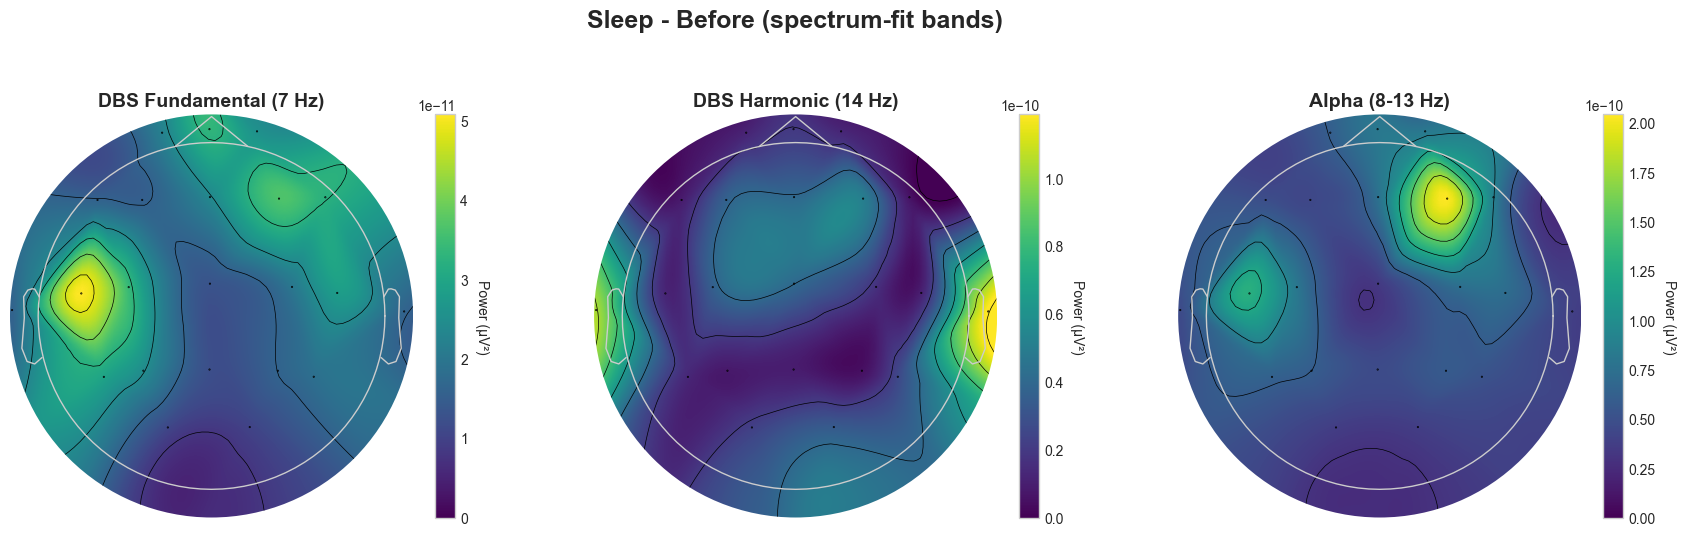

Found 22 channels with standard positions for plotting.
Saving figure to figs_sleep/topomaps_after_sleep.png...


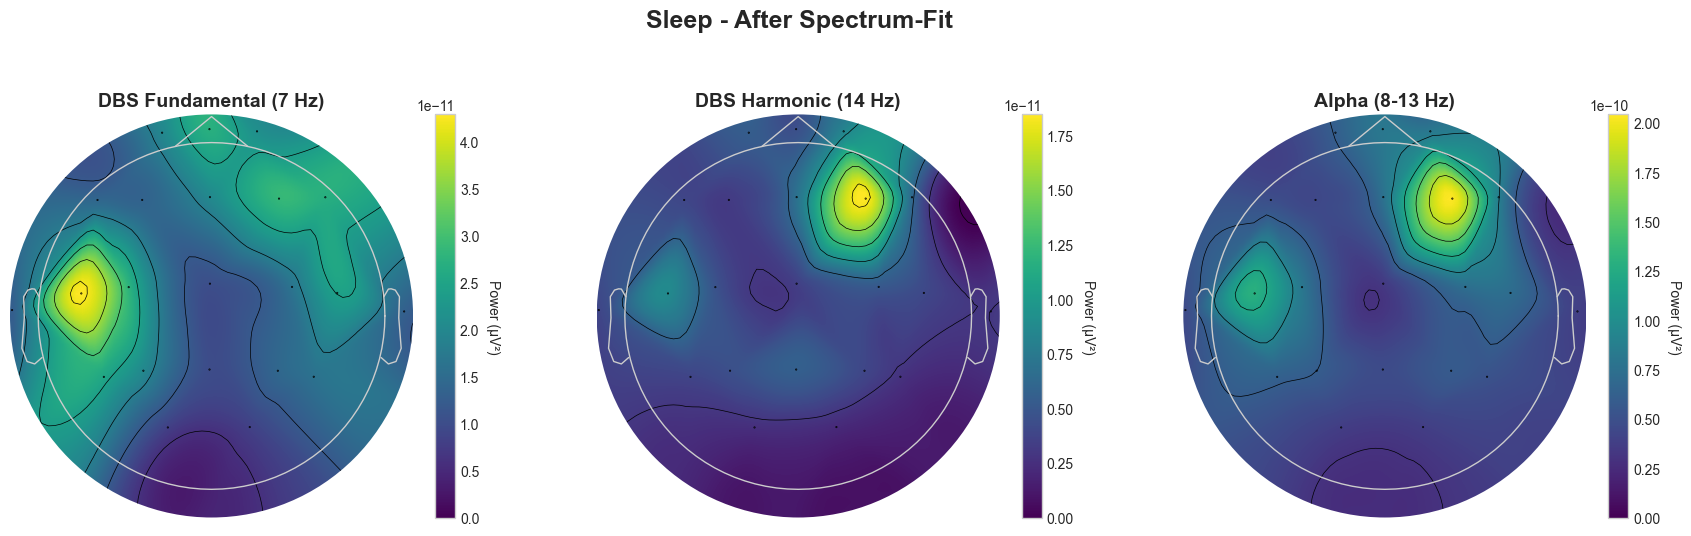

Saved topomaps for before/after.
Done sleep.

--- AWAKE ---
Channel types set for 46 channels.
Montage set successfully!
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reference set using channels: average
Effective window size : 16.000 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------

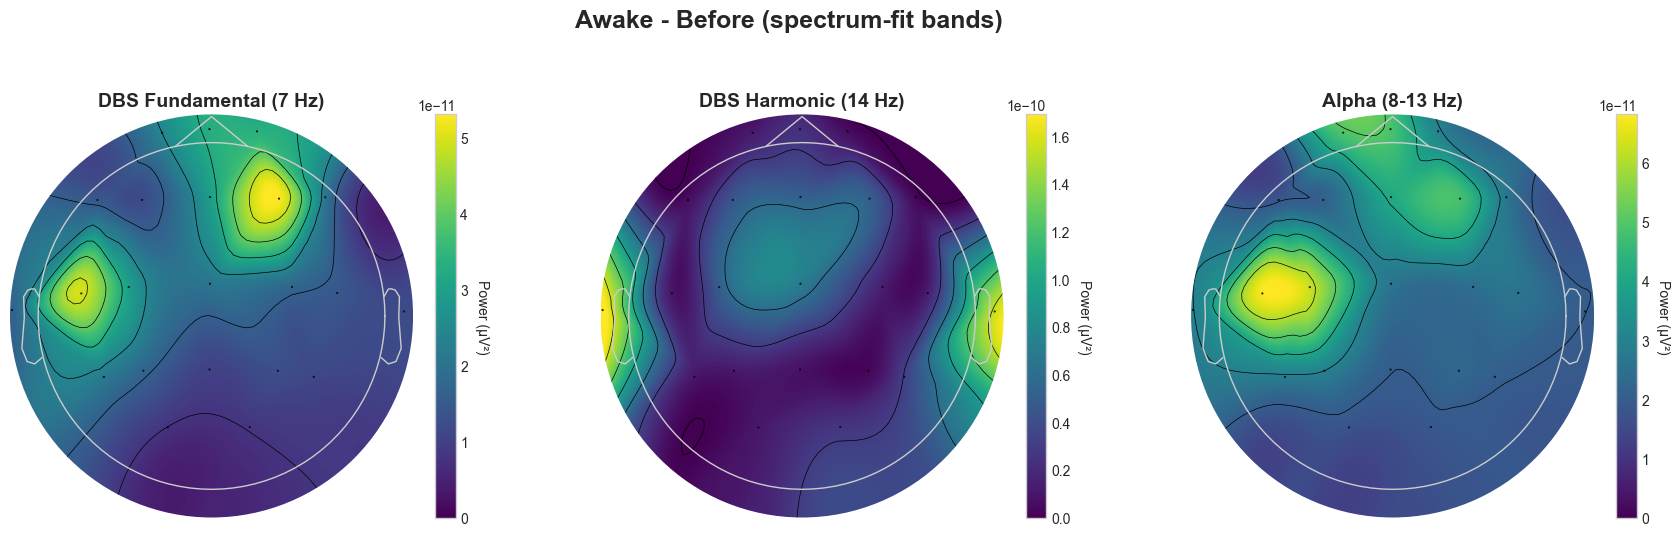

Found 22 channels with standard positions for plotting.
Saving figure to figs_awake/topomaps_after_awake.png...


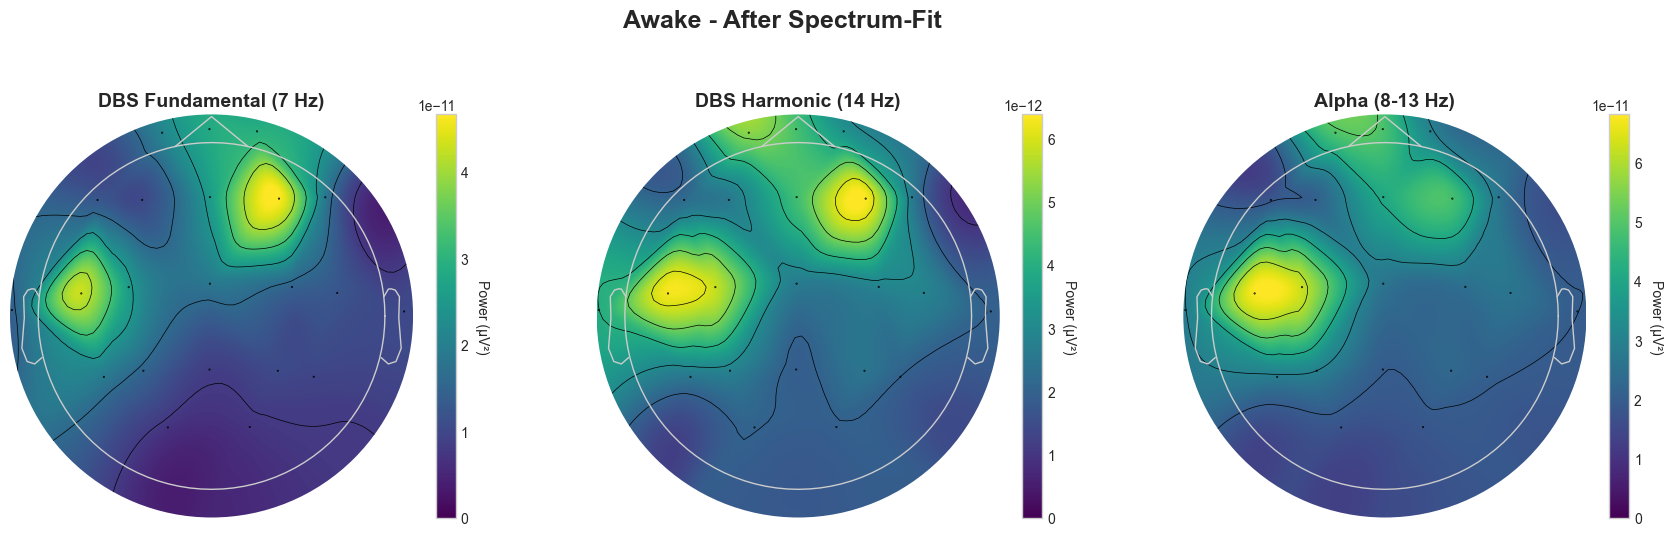

Saved topomaps for before/after.
Done awake.

All saved files:
- figs_sleep/combined_comparison_sleep.png
- figs_sleep/psd_full_sleep.png
- figs_sleep/metrics_summary_sleep.csv
- figs_sleep/topomaps_before_sleep.png
- figs_sleep/topomaps_after_sleep.png
- figs_awake/combined_comparison_awake.png
- figs_awake/psd_full_awake.png
- figs_awake/metrics_summary_awake.csv
- figs_awake/topomaps_before_awake.png
- figs_awake/topomaps_after_awake.png


In [62]:
# %% [markdown]
# ### Enhanced batch processing & comparison (0–120 Hz) — multi-band preservation & subplots

# %%
import os
from sklearn.metrics import mean_squared_error

# Color palette (poster friendly)
COLORS = {
    'Baseline': '#6c757d',
    'Zapline': '#012169',          # navy (user requested navy background earlier - we use navy line)
    'Spectrum Fit': '#2a6f97',
    'Freq-Domain Hampel': '#d1495b',
    'Time-Domain Hampel': '#f6a01a'
}

BANDS = {
    'Delta (0.5–4 Hz)': (0.5, 4),
    'Theta (4–8 Hz)': (4, 8),
    'Alpha (8–13 Hz)': (8, 13),
    'Beta (13–30 Hz)': (13, 30),
    'Gamma (30–80 Hz)': (30, 80)
}

def harmonics_up_to(max_hz, base_freq):
    return np.arange(base_freq, max_hz + 1e-8, base_freq)

def band_power_from_psd(psd_vec, freqs, band):
    fmin, fmax = band
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    if len(idx) == 0: return 0.0
    df = freqs[1] - freqs[0]
    return np.sum(psd_vec[idx]) * df

def rmse_log_nonartifact(freqs, psd_raw, psd_clean, artifact_centers, halfwidth=0.5, fmin=0.5, fmax=120.0):
    mask = (freqs >= fmin) & (freqs <= fmax)
    art_mask = np.zeros_like(mask, dtype=bool)
    for c in artifact_centers:
        idx = np.where((freqs >= c-halfwidth) & (freqs <= c+halfwidth))[0]
        art_mask[idx] = True
    valid_idx = np.where(mask & ~art_mask)[0]
    if len(valid_idx) == 0: return np.nan
    return np.sqrt(mean_squared_error(np.log1p(psd_raw[valid_idx]), np.log1p(psd_clean[valid_idx])))

def harmonic_attenuation_df(freqs, psd_raw, psd_clean, harm_list, halfwidth=0.5):
    rows = []
    for h in harm_list:
        idx = np.where((freqs >= h-halfwidth) & (freqs <= h+halfwidth))[0]
        p_raw = np.sum(psd_raw[idx]) * (freqs[1]-freqs[0]) if len(idx)>0 else 0.0
        p_clean = np.sum(psd_clean[idx]) * (freqs[1]-freqs[0]) if len(idx)>0 else 0.0
        att = 10 * np.log10(p_raw / p_clean) if (p_raw>0 and p_clean>0) else np.nan
        rows.append({'harmonic': float(h), 'p_raw': p_raw, 'p_clean': p_clean, 'atten_dB': att})
    return pd.DataFrame(rows)

# Main enhanced loop
states = {'sleep': raw_sleep, 'awake': raw_awake}
saved_files = []

for state_name, raw in states.items():
    try:
        print(f"\n--- {state_name.upper()} ---")
        out_dir = f"figs_{state_name}"
        os.makedirs(out_dir, exist_ok=True)

        # Basic housekeeping
        try: set_custom_channel_types(raw)
        except: pass
        try: set_eeg_montage(raw)
        except: pass
        try: set_reference(raw)
        except: pass

        # Choose channel to display (Cz preferred)
        ch_name = 'Cz' if 'Cz' in raw.ch_names else raw.ch_names[0]
        ch_idx = raw.ch_names.index(ch_name)

        # PSD params (120 Hz)
        fmax = 120.0
        psd_params = dict(fmin=0.5, fmax=fmax, n_fft=4096, n_overlap=1024, n_per_seg=2048)

        freqs_raw, psd_raw = get_psd(raw, **psd_params)

        # Baseline filter
        filtered = raw.copy()
        apply_frequency_filter(filtered, l_freq=0.5, h_freq=40.0, powerline_freq=powerline_freq)
        freqs_base, psd_base = get_psd(filtered, **psd_params)

        # Create harmonics (DBS + powerline) up to 120 Hz
        dbs_harmonics = harmonics_up_to(fmax, dbs_freq)
        pl_harmonics = harmonics_up_to(fmax, powerline_freq)
        all_artifacts = np.union1d(dbs_harmonics, pl_harmonics)

        # Apply methods
        try:
            raw_zapline, _scores, _details, _freqs = apply_zapline_to_raw(filtered.copy(), line_freqs=dbs_harmonics, verbose=False)
        except Exception as e:
            print("Zapline error:", e); raw_zapline = filtered.copy()
        try:
            freqs_to_remove = np.union1d(dbs_harmonics, pl_harmonics)
            raw_spec = filtered.copy().notch_filter(freqs=freqs_to_remove, method='spectrum_fit', n_jobs=1, verbose=False)
        except Exception as e:
            print("Spectrum-fit error:", e); raw_spec = filtered.copy()
        try:
            raw_hampel_freq = apply_freq_domain_hampel(filtered.copy(), window_size=201, n_sigmas=3)
        except Exception as e:
            print("Freq-Hampel error:", e); raw_hampel_freq = filtered.copy()
        try:
            raw_hampel_time = apply_time_domain_hampel(filtered.copy(), window_size=int(0.2*filtered.info['sfreq']), n_sigmas=3)
        except Exception as e:
            print("Time-Hampel error:", e); raw_hampel_time = filtered.copy()

        # PSDs for all
        _, psd_zap = get_psd(raw_zapline, **psd_params)
        _, psd_spec = get_psd(raw_spec, **psd_params)
        _, psd_hf = get_psd(raw_hampel_freq, **psd_params)
        _, psd_ht = get_psd(raw_hampel_time, **psd_params)

        methods = {
            'Baseline': psd_base[ch_idx],
            'Zapline': psd_zap[ch_idx],
            'Spectrum Fit': psd_spec[ch_idx],
            'Freq-Domain Hampel': psd_hf[ch_idx],
            'Time-Domain Hampel': psd_ht[ch_idx]
        }

        # ---- Create combined figure: 2 rows x 3 columns ----
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios':[1,1]}, constrained_layout=True)
        # Row 1: Full PSD (0-120) and Zoom (0-45)
        ax_full = axes[0,0]
        ax_zoom = axes[0,1]
        ax_methods = axes[0,2]  # will show per-harmonic attenuation overlay small

        # Row 2: Band preservation bars and aggregated metrics
        ax_bands = axes[1,0]
        ax_metrics = axes[1,1]
        ax_rmse = axes[1,2]

        # Full PSD plot
        for name, vec in methods.items():
            ax_full.semilogy(freqs_base, vec, label=name, color=COLORS.get(name, '#333333'), linewidth=1.6 if name!='Baseline' else 2.0, alpha=0.95)
        # harmonic markers
        for h in dbs_harmonics:
            ax_full.axvline(h, color='orange', linestyle=':', alpha=0.25)
        for h in pl_harmonics:
            ax_full.axvline(h, color='red', linestyle='--', alpha=0.15)
        ax_full.set_xlim(0, fmax)
        ax_full.set_xlabel('Frequency (Hz)')
        ax_full.set_ylabel('PSD (µV²/Hz)')
        ax_full.set_title(f'{state_name.capitalize()} — PSD 0–120 Hz ({ch_name})')
        ax_full.grid(True, which='both', linestyle='--', alpha=0.3)
        ax_full.legend(fontsize=9, loc='upper right')

        # Zoom (0-45)
        for name, vec in methods.items():
            ax_zoom.semilogy(freqs_base, vec, label=name, color=COLORS.get(name, '#333333'), linewidth=1.6 if name!='Baseline' else 2.0, alpha=0.95)
        for h in dbs_harmonics:
            if h <= 45: ax_zoom.axvline(h, color='orange', linestyle=':', alpha=0.35)
        ax_zoom.set_xlim(0,45)
        ax_zoom.set_xlabel('Frequency (Hz)')
        ax_zoom.set_ylabel('PSD (µV²/Hz)')
        ax_zoom.set_title('Zoom 0–45 Hz')
        ax_zoom.grid(True, which='both', linestyle='--', alpha=0.3)
        ax_zoom.legend(fontsize=8)

        # Per-harmonic attenuation plot (overlay lines)
        per_method_dfs = {}
        for method_name, vec in [('Zapline', psd_zap[ch_idx]), ('Spectrum Fit', psd_spec[ch_idx]),
                                 ('Freq-Domain Hampel', psd_hf[ch_idx]), ('Time-Domain Hampel', psd_ht[ch_idx])]:
            df_h = harmonic_attenuation_df(freqs_base, psd_base[ch_idx], vec, dbs_harmonics, halfwidth=0.5)
            per_method_dfs[method_name] = df_h
            ax_methods.plot(df_h['harmonic'], df_h['atten_dB'], marker='o', label=method_name, color=COLORS[method_name], linewidth=1.6)
        ax_methods.set_xlabel('Harmonic (Hz)')
        ax_methods.set_ylabel('Attenuation (dB)')
        ax_methods.set_title('Per-harmonic attenuation (±0.5 Hz)')
        ax_methods.grid(True, linestyle='--', alpha=0.3)
        ax_methods.legend(fontsize=8)

                # ---- Band preservation: compute band powers and show % preserved relative to baseline for each method ----
        band_names = list(BANDS.keys())
        # baseline band powers (for the chosen channel)
        band_base_powers = {bn: band_power_from_psd(psd_base[ch_idx], freqs_base, BANDS[bn]) for bn in band_names}

        # build DataFrame: rows = band, columns = methods
        band_pres_by_band = {}
        for bn in band_names:
            vals = []
            for method_name, vec in [('Zapline', psd_zap[ch_idx]), ('Spectrum Fit', psd_spec[ch_idx]),
                                     ('Freq-Domain Hampel', psd_hf[ch_idx]), ('Time-Domain Hampel', psd_ht[ch_idx])]:
                base_power = band_base_powers[bn]
                p = band_power_from_psd(vec, freqs_base, BANDS[bn])
                pct = 100.0 * (p / base_power) if base_power > 0 else np.nan
                vals.append(pct)
            band_pres_by_band[bn] = vals
        band_pres_df = pd.DataFrame(band_pres_by_band, index=['Zapline','Spectrum Fit','Freq-Domain Hampel','Time-Domain Hampel'])
        # transpose so x-axis = bands, groups = methods
        band_pres_plot = band_pres_df.T

        # plotting: grouped bars per band
        band_pres_plot.plot(kind='bar', ax=ax_bands, color=[COLORS.get(m,'#888') for m in band_pres_df.index], width=0.8)
        ax_bands.set_ylabel('Preservation (%)')
        ax_bands.set_ylim(0, 130)
        ax_bands.set_title('Band Preservation (%) by Method')
        ax_bands.grid(axis='y', linestyle='--', alpha=0.3)
        ax_bands.set_xticklabels([b.replace(' (','\n(') for b in band_pres_plot.index], rotation=25, ha='right')
        ax_bands.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


        # Aggregated metrics: mean harmonic attenuation (dB), RMSE_nonartifact (log PSD), broadband preservation
        metrics = []
        for method_name, vec in [('Zapline', psd_zap[ch_idx]), ('Spectrum Fit', psd_spec[ch_idx]),
                                 ('Freq-Domain Hampel', psd_hf[ch_idx]), ('Time-Domain Hampel', psd_ht[ch_idx])]:
            df_h = per_method_dfs[method_name]
            mean_att = df_h['atten_dB'].dropna().mean()
            rmsev = rmse_log_nonartifact(freqs_base, psd_base[ch_idx], vec, dbs_harmonics, halfwidth=0.5, fmin=0.5, fmax=fmax)
            broadband_pres = 100.0 * (np.sum(vec) / np.sum(psd_base[ch_idx]))  # approximate percent (same df)
            metrics.append({'Method': method_name, 'MeanAtt_dB': mean_att, 'RMSE_logPSD': rmsev, 'BroadbandPres_%': broadband_pres})
        df_metrics = pd.DataFrame(metrics).set_index('Method')

        # Metrics bar plots (two small bars: MeanAtt and RMSE)
        df_metrics[['MeanAtt_dB']].plot(kind='bar', ax=ax_metrics, color=[COLORS[m] for m in df_metrics.index])
        ax_metrics.set_title('Mean Harmonic Attenuation (dB)')
        ax_metrics.set_ylabel('dB'); ax_metrics.grid(axis='y', linestyle='--', alpha=0.3)
        ax_metrics.tick_params(axis='x', rotation=25)

        df_metrics[['RMSE_logPSD']].plot(kind='bar', ax=ax_rmse, color=[COLORS[m] for m in df_metrics.index])
        ax_rmse.set_title('RMSE (log PSD) on non-artifact bins')
        ax_rmse.set_ylabel('RMSE'); ax_rmse.grid(axis='y', linestyle='--', alpha=0.3)
        ax_rmse.tick_params(axis='x', rotation=25)

        fig.suptitle(f'{state_name.capitalize()} — Method Comparison (channel {ch_name})', fontsize=16, fontweight='bold')
        fname_combined = os.path.join(out_dir, f'combined_comparison_{state_name}.png')
        fig.savefig(fname_combined, dpi=300, bbox_inches='tight')
        plt.close(fig)
        saved_files.append(fname_combined)
        print("Saved:", fname_combined)

        # Also save the full PSD and a clean zoom separately (optional)
        # Full PSD (single large)
        fig_full, axf = plt.subplots(1,1, figsize=(12,5), constrained_layout=True)
        for name, vec in methods.items():
            axf.semilogy(freqs_base, vec, label=name, color=COLORS.get(name, '#333'), linewidth=1.6 if name!='Baseline' else 2.0)
        for h in dbs_harmonics: axf.axvline(h, color='orange', linestyle=':', alpha=0.25)
        axf.set_xlim(0, fmax); axf.set_xlabel('Frequency (Hz)'); axf.set_ylabel('PSD (µV²/Hz)')
        axf.set_title(f'{state_name.capitalize()} — PSD 0–120 Hz ({ch_name})')
        axf.grid(True, which='both', linestyle='--', alpha=0.3)
        axf.legend(fontsize=9)
        fname_full2 = os.path.join(out_dir, f'psd_full_{state_name}.png')
        fig_full.savefig(fname_full2, dpi=300, bbox_inches='tight')
        plt.close(fig_full)
        saved_files.append(fname_full2)

        # Save metrics summary CSV and band-preservation table
        csv_metrics = os.path.join(out_dir, f'metrics_summary_{state_name}.csv')
        df_metrics.to_csv(csv_metrics)
        saved_files.append(csv_metrics)
        band_pres_df.to_csv(os.path.join(out_dir, f'band_preservation_{state_name}.csv'))
        print("Saved CSVs:", csv_metrics)

        # Save per-harmonic attenuation CSVs for each method
        for mname, df_h in per_method_dfs.items():
            df_h.to_csv(os.path.join(out_dir, f'harmonic_attenuation_{mname.replace(" ","_")}_{state_name}.csv'), index=False)

        # Optional: Topomap before vs after (spectrum-fit) for relevant bands (uses your plot_band_power_topomaps)
        try:
            eeg_picks = mne.pick_types(filtered.info, eeg=True, exclude='bads')
            ch_names_local = [filtered.ch_names[i] for i in eeg_picks]
            # compute band powers for a few bands (DBS fundamental, second harmonic, alpha)
            dbs_bands_local = {
                f'DBS Fundamental ({dbs_freq} Hz)': (dbs_freq-0.5, dbs_freq+0.5),
                f'DBS Harmonic ({2*dbs_freq} Hz)': (2*dbs_freq-0.5, 2*dbs_freq+0.5),
                'Alpha (8-13 Hz)': (8,13)
            }
            psd_before, freqs_before = psd_base, freqs_base
            # calculate band powers (re-using your calculate_band_powers)
            df_before = calculate_band_powers(psd_before, freqs_base, ch_names_local, bands=dbs_bands_local)
            df_after = calculate_band_powers(psd_spec, freqs_base, ch_names_local, bands=dbs_bands_local)
            # plot and save
            fname_topo = os.path.join(out_dir, f'topomaps_before_after_spec_{state_name}.png')
            plot_band_power_topomaps(filtered, {k: df_before[k].values for k in df_before.columns},
                                     suptitle=f"{state_name.capitalize()} - Before (spectrum-fit bands)", save_path=os.path.join(out_dir, f'topomaps_before_{state_name}.png'))
            plot_band_power_topomaps(raw_spec, {k: df_after[k].values for k in df_after.columns},
                                     suptitle=f"{state_name.capitalize()} - After Spectrum-Fit", save_path=os.path.join(out_dir, f'topomaps_after_{state_name}.png'))
            saved_files += [os.path.join(out_dir, f'topomaps_before_{state_name}.png'), os.path.join(out_dir, f'topomaps_after_{state_name}.png')]
            print("Saved topomaps for before/after.")
        except Exception as e:
            print("Topomap step failed:", e)

        print(f"Done {state_name}.")

    except Exception as ex:
        print("Error processing", state_name, ex)

print("\nAll saved files:")
for f in saved_files:
    print("-", f)
